# Exploratory Data Analysis

**Thesis:** Predicting Agentic Pull Request Rejection: An Empirical Comparison of NLP Approaches
  
**Author:** Victoria Angela Vizmonte  

This notebook documents the exploratory data analysis conducted on the AIDev-Pop dataset prior to modeling. It covers the final study population pipeline, class distribution and rejection rates across the temporal split, agent and task type breakdowns, programming language coverage, and code diff size distribution. All figures produced here are saved to `results/eda/` for use in the thesis.

---

| Item | Description |
|---|---|
| Dataset | AIDev-Pop (AIDev subset, repos ≥ 500 stars) |
| Timeframe | December 2024 – July 2025 |
| Final study population | 10,648 PRs |
| Target variable | Binary: rejected (1) vs. accepted (0) |
| Data split | 70/15/15 temporal split (Train=7,453 / Val=1,598 / Test=1,597) |
| Overall rejection rate (test) | ~35% |
| Results output | `results/eda/` |

In [3]:
# ---------------------------------------------------------------
# CONFIGURE THIS PATH before running any other cell.
# Set DRIVE_BASE to the folder on your Google Drive that contains
# data/, src/, results/, and requirements.txt for this project.
# Example: if you placed the shared folder at the root of your
# Drive, set this to '/content/drive/MyDrive/AgenticPRRejection'
# ---------------------------------------------------------------

from google.colab import drive
import subprocess, sys
from pathlib import Path

DRIVE_BASE = Path('/content/drive/MyDrive/Thesis/AgenticPRRejection')   # replace with your own path

# Mount Google Drive (data and src/ live here)
drive.mount('/content/drive')
print("Drive mounted")

# Make src/ modules importable directly from Drive
sys.path.insert(0, f'{DRIVE_BASE}/src')
print("src/ added to path")

# Install dependencies
subprocess.run(
    ['pip', 'install', '-q', '-r',
     f'{DRIVE_BASE}/requirements.txt'],
    check=True
)
print("Dependencies installed")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted
src/ added to path
Dependencies installed


In [4]:
# Imports and global style
import sys

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import os

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_raw_tables

# Color Palette
COLOR_ACCEPTED = "#357768"
COLOR_REJECTED = "#723e46"

CATEGORICAL_PALETTE = [
    "#156798",  # dark teal
    "#ea9e2b",  # warm orange
    "#a45a25",  # rust
    "#939e47",  # forest green
    "#d0a731",  # olive
    "#723e46",  # maroon
    "#357768",  # teal-blue
    "#2290bf",  # medium blue
]

mpl.rcParams.update({
    "font.family":          "serif",
    "font.size":            10,
    "axes.titlesize":       11,
    "axes.labelsize":       10,
    "xtick.labelsize":      9,
    "ytick.labelsize":      9,
    "legend.fontsize":      9,
    "figure.dpi":           150,
    "savefig.dpi":          300,
    "savefig.bbox":         "tight",
    "savefig.pad_inches":   0.05,
    "axes.spines.top":      False,
    "axes.spines.right":    False,
    "axes.grid":            True,
    "grid.alpha":           0.3,
    "grid.linestyle":       "--",
    "text.usetex":          False,
    "axes.prop_cycle":      mpl.cycler(color=CATEGORICAL_PALETTE),
})

sns.set_style("white")

In [5]:
# Drive base path
from pathlib import Path
DRIVE_BASE = Path(DRIVE_BASE)
print(f'DRIVE_BASE set to: {DRIVE_BASE}')
print(f'Exists on Drive:   {DRIVE_BASE.exists()}')

DRIVE_BASE set to: /content/drive/MyDrive/Thesis/AgenticPRRejection
Exists on Drive:   True


## Data Loading and Preprocessing

In [6]:
# Load tables from Google Drive and HuggingFace

# Pipeline tables (on Drive via download_aidev_data_colab.ipynb)
tables = load_raw_tables(['pull_request', 'repository', 'pr_commits', 'pr_commit_details', 'pr_task_type'])
pr_df = tables['pull_request']
repo_df = tables['repository']
pr_commits_df = tables['pr_commits']
pr_commit_details_df = tables['pr_commit_details']
pr_task_type_df = tables['pr_task_type']

# Extra EDA tables — not in the pipeline scope; loaded directly from HuggingFace
HF_BASE = "hf://datasets/hao-li/AIDev"
pr_timeline_df           = pd.read_parquet(f"{HF_BASE}/pr_timeline.parquet")
pr_comments_df           = pd.read_parquet(f"{HF_BASE}/pr_comments.parquet")
pr_reviews_df            = pd.read_parquet(f"{HF_BASE}/pr_reviews.parquet")
pr_review_comments_v2_df = pd.read_parquet(f"{HF_BASE}/pr_review_comments_v2.parquet")
issue_df                 = pd.read_parquet(f"{HF_BASE}/issue.parquet")
related_issue_df         = pd.read_parquet(f"{HF_BASE}/related_issue.parquet")
user_df                  = pd.read_parquet(f"{HF_BASE}/user.parquet")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [7]:
# Sanity check: print loaded table shapes
print("Loaded tables:")
print(f"  pull_request: {pr_df.shape}")
print(f"  repository: {repo_df.shape}")
print(f"  pr_timeline: {pr_timeline_df.shape}")
print(f"  pr_comments: {pr_comments_df.shape}")
print(f"  pr_reviews: {pr_reviews_df.shape}")
print(f"  pr_review_comments_v2: {pr_review_comments_v2_df.shape}")
print(f"  pr_commits: {pr_commits_df.shape}")
print(f"  pr_commit_details: {pr_commit_details_df.shape}")
print(f"  pr_task_type: {pr_task_type_df.shape}")
print(f"  issue: {issue_df.shape}")
print(f"  related_issue: {related_issue_df.shape}")
print(f"  user: {user_df.shape}")

Loaded tables:
  pull_request: (33596, 14)
  repository: (2807, 7)
  pr_timeline: (325500, 8)
  pr_comments: (39122, 7)
  pr_reviews: (28875, 7)
  pr_review_comments_v2: (26868, 15)
  pr_commits: (88576, 5)
  pr_commit_details: (711923, 14)
  pr_task_type: (33596, 6)
  issue: (4614, 9)
  related_issue: (4923, 3)
  user: (1796, 5)


In [8]:
# Normalize repo id column names across tables
if "id" in repo_df.columns and "repo_id" not in repo_df.columns:
    repo_df = repo_df.rename(columns={"id": "repo_id"})
if "repo_id" not in pr_df.columns and "repository_id" in pr_df.columns:
    pr_df = pr_df.rename(columns={"repository_id": "repo_id"})
if "repo" in pr_df.columns and "repo_id" not in pr_df.columns:
    pr_df = pr_df.rename(columns={"repo": "repo_id"})

popular_repos = repo_df[repo_df.get("stars", 0) >= 500].copy()
popular_repo_ids = set(popular_repos["repo_id"].unique())
print(f"Popular repos (stars>=500): {len(popular_repo_ids)}")

Popular repos (stars>=500): 1479


In [9]:
# Filter PRs to popular repos (stars >= 500)
pr_df_f = pr_df[pr_df["repo_id"].isin(popular_repo_ids)].copy()
popular_pr_ids = set(pr_df_f["id"].unique()) if "id" in pr_df_f.columns else set()
print(f"PRs in popular repos: {len(popular_pr_ids)}")

PRs in popular repos: 12373


In [10]:
# Define normalize_df() helper
def normalize_df(df, table_name=None):
    df2 = df.copy()
    if table_name == 'pr_task_type':
        if "id" in df2.columns and "pr_id" not in df2.columns:
            df2 = df2.rename(columns={"id": "pr_id"})
            return df2
    if "repository_id" in df2.columns and "repo_id" not in df2.columns:
        df2 = df2.rename(columns={"repository_id": "repo_id"})
    if "pull_request_id" in df2.columns and "pr_id" not in df2.columns:
        df2 = df2.rename(columns={"pull_request_id": "pr_id"})
    if "pr" in df2.columns and "pr_id" not in df2.columns:
        df2 = df2.rename(columns={"pr": "pr_id"})
    return df2

In [11]:
# Normalize commonly referenced EDA tables
pr_timeline_df = normalize_df(pr_timeline_df, 'pr_timeline')
pr_comments_df = normalize_df(pr_comments_df, 'pr_comments')
pr_reviews_df = normalize_df(pr_reviews_df, 'pr_reviews')
pr_review_comments_v2_df = normalize_df(pr_review_comments_v2_df, 'pr_review_comments_v2')
pr_commits_df = normalize_df(pr_commits_df, 'pr_commits')
pr_commit_details_df = normalize_df(pr_commit_details_df, 'pr_commit_details')
pr_task_type_df = normalize_df(pr_task_type_df, 'pr_task_type')
related_issue_df = normalize_df(related_issue_df, 'related_issue')

print("Column check after normalization:")
print(f"  pr_task_type columns: {list(pr_task_type_df.columns)}")
print(f"  pr_review_comments_v2 columns: {list(pr_review_comments_v2_df.columns)}")

Column check after normalization:
  pr_task_type columns: ['agent', 'pr_id', 'title', 'reason', 'type', 'confidence']
  pr_review_comments_v2 columns: ['id', 'pull_request_review_id', 'user', 'user_type', 'diff_hunk', 'path', 'position', 'original_position', 'commit_id', 'original_commit_id', 'body', 'pull_request_url', 'created_at', 'updated_at', 'in_reply_to_id']


In [12]:
# Define filter_by_repo_or_pr() helper
def filter_by_repo_or_pr(df):
    if "repo_id" in df.columns:
        return df[df["repo_id"].isin(popular_repo_ids)].copy()
    if "pr_id" in df.columns:
        return df[df["pr_id"].isin(popular_pr_ids)].copy()
    return df.iloc[0:0].copy()

In [13]:
# Apply filters to all EDA tables
pr_timeline_df_f = filter_by_repo_or_pr(pr_timeline_df)
pr_comments_df_f = filter_by_repo_or_pr(pr_comments_df)
pr_reviews_df_f = filter_by_repo_or_pr(pr_reviews_df)
pr_review_comments_v2_df_f = filter_by_repo_or_pr(pr_review_comments_v2_df)
pr_commits_df_f = filter_by_repo_or_pr(pr_commits_df)
pr_commit_details_df_f = filter_by_repo_or_pr(pr_commit_details_df)
pr_task_type_df_f = filter_by_repo_or_pr(pr_task_type_df)

In [14]:
# Filter pr_review_comments_v2 via pr_reviews join
if len(pr_reviews_df_f) > 0 and "id" in pr_reviews_df_f.columns:
    popular_review_ids = set(pr_reviews_df_f["id"].unique())
    if "pull_request_review_id" in pr_review_comments_v2_df.columns:
        pr_review_comments_v2_df_f = pr_review_comments_v2_df[
            pr_review_comments_v2_df["pull_request_review_id"].isin(popular_review_ids)
        ].copy()
    else:
        pr_review_comments_v2_df_f = pr_review_comments_v2_df.iloc[0:0].copy()
else:
    pr_review_comments_v2_df_f = pr_review_comments_v2_df.iloc[0:0].copy()

print(f"Filtered pr_review_comments_v2: {pr_review_comments_v2_df_f.shape}")

Filtered pr_review_comments_v2: (18388, 15)


In [15]:
# Filter related_issue and issue tables
if "pr_id" in related_issue_df.columns:
    related_issue_df_f = related_issue_df[related_issue_df["pr_id"].isin(popular_pr_ids)].copy()
else:
    related_issue_df_f = related_issue_df.iloc[0:0].copy()

if "issue_id" in related_issue_df_f.columns:
    linked_issue_ids = set(related_issue_df_f["issue_id"].unique())
    issue_df_f = issue_df[issue_df["id"].isin(linked_issue_ids)].copy()
else:
    issue_df_f = issue_df.iloc[0:0].copy()

In [16]:
# Filter user table to PR participants
if "user_id" in pr_df_f.columns:
    user_ids = set(pr_df_f["user_id"].unique())
    user_df_f = user_df[user_df["id"].isin(user_ids)].copy()
else:
    user_df_f = user_df.iloc[0:0].copy()

In [17]:
# Set repo_df_f to popular_repos
repo_df_f = popular_repos

In [18]:
# Sanity check: print filtered table shapes
print("Filtered shapes:")
print(f"  pull_request: {pr_df_f.shape}")
print(f"  repository (popular): {repo_df_f.shape}")
print(f"  pr_timeline: {pr_timeline_df_f.shape}")
print(f"  pr_comments: {pr_comments_df_f.shape}")
print(f"  pr_reviews: {pr_reviews_df_f.shape}")
print(f"  pr_review_comments_v2: {pr_review_comments_v2_df_f.shape}")
print(f"  pr_commits: {pr_commits_df_f.shape}")
print(f"  pr_commit_details: {pr_commit_details_df_f.shape}")
print(f"  pr_task_type: {pr_task_type_df_f.shape}")
print(f"  related_issue: {related_issue_df_f.shape}")
print(f"  issue (linked via related_issue): {issue_df_f.shape}")
print(f"  user: {user_df_f.shape}")

Filtered shapes:
  pull_request: (12373, 14)
  repository (popular): (1479, 7)
  pr_timeline: (177301, 8)
  pr_comments: (27949, 7)
  pr_reviews: (20484, 7)
  pr_review_comments_v2: (18388, 15)
  pr_commits: (49418, 5)
  pr_commit_details: (399223, 14)
  pr_task_type: (12373, 6)
  related_issue: (3355, 3)
  issue (linked via related_issue): (3111, 9)
  user: (1032, 5)


In [19]:
# Define rejection / merge / open flags on pr_df_f
pr_df_f["is_merged"] = pr_df_f["merged_at"].notna()
pr_df_f["is_rejected"] = (
    (pr_df_f["state"] == "closed") &
    (pr_df_f["merged_at"].isna())
)
pr_df_f["is_open"] = pr_df_f["state"] == "open"

## Part 1 — Preliminary Data Characterizations (11,048 PRs, pre-diff-size filtering)

This section discusses the Preliminary Data Characterizations and Analyses made on the pre-filter population of 11,048 AI Dev PRs (specifically Section 4.2.1 of the Thesis), where we analyze the Text and Code Diffs of the subset.

/tmp/ipykernel_2342/1826713294.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  eda_pr_closed_df['month']      = eda_pr_closed_df['created_at'].dt.to_period('M')


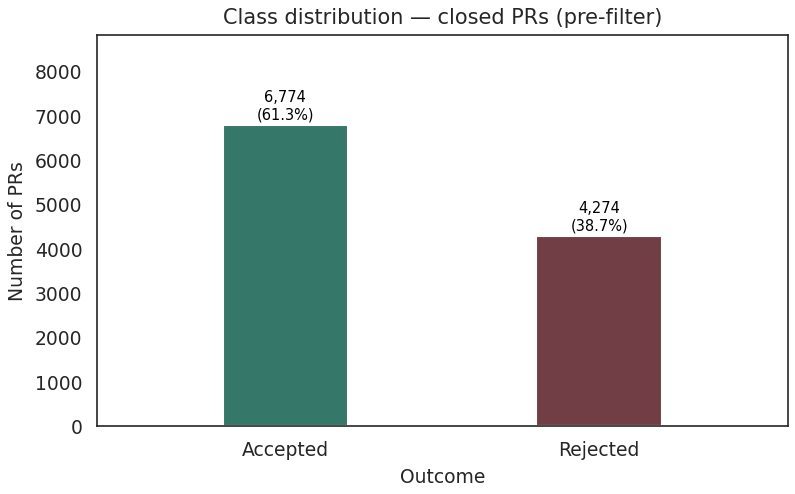


pre_filter_pop: 11,048 PRs  |  rej. rate: 0.3869


In [20]:
# Remove open PRs; parse dates; closed-PR class balance
eda_pr_closed_df = pr_df_f[~pr_df_f["is_open"]].copy()

# Parse timestamps and add month period
eda_pr_closed_df['created_at'] = pd.to_datetime(eda_pr_closed_df['created_at'])
eda_pr_closed_df['month']      = eda_pr_closed_df['created_at'].dt.to_period('M')

rejection_rate = pr_df_f["is_rejected"].mean()
merge_rate     = pr_df_f["is_merged"].mean()

n_rej        = int(eda_pr_closed_df["is_rejected"].sum())
n_mer        = int(eda_pr_closed_df["is_merged"].sum())
total_closed = len(eda_pr_closed_df)

# Class distribution charts y/axis scale
CLASS_DIST_YLIM = max(n_mer, n_rej) * 1.3

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.bar(["Accepted", "Rejected"], [n_mer, n_rej],
       width=0.4, color=[COLOR_ACCEPTED, COLOR_REJECTED])
ax.text(0, n_mer + CLASS_DIST_YLIM * 0.01,
        f"{n_mer:,}\n({n_mer/total_closed*100:.1f}%)",
        ha="center", va="bottom", fontsize=7, color="black")
ax.text(1, n_rej + CLASS_DIST_YLIM * 0.01,
        f"{n_rej:,}\n({n_rej/total_closed*100:.1f}%)",
        ha="center", va="bottom", fontsize=7, color="black")
ax.set_xlim(-0.6, 1.6)
ax.set_ylim(0, CLASS_DIST_YLIM)
ax.set_title("Class distribution — closed PRs (pre-filter)")
ax.set_xlabel("Outcome")
ax.set_ylabel("Number of PRs")
ax.title.set_fontsize(10)
ax.xaxis.label.set_fontsize(9)
ax.yaxis.label.set_fontsize(9)
plt.tight_layout()
OUT_DIR = DRIVE_BASE / 'results' / 'final' / 'eda'
os.makedirs(OUT_DIR, exist_ok=True)
fig.savefig(os.path.join(OUT_DIR, "fig_p0_class_distribution_prefilter.pdf"))
plt.show()

pre_filter_pop = eda_pr_closed_df
pre_filter_pop['label'] = pre_filter_pop['is_rejected'].astype(int)
print(f"\npre_filter_pop: {len(pre_filter_pop):,} PRs  |  rej. rate: {pre_filter_pop['label'].mean():.4f}")

### Text Analysis

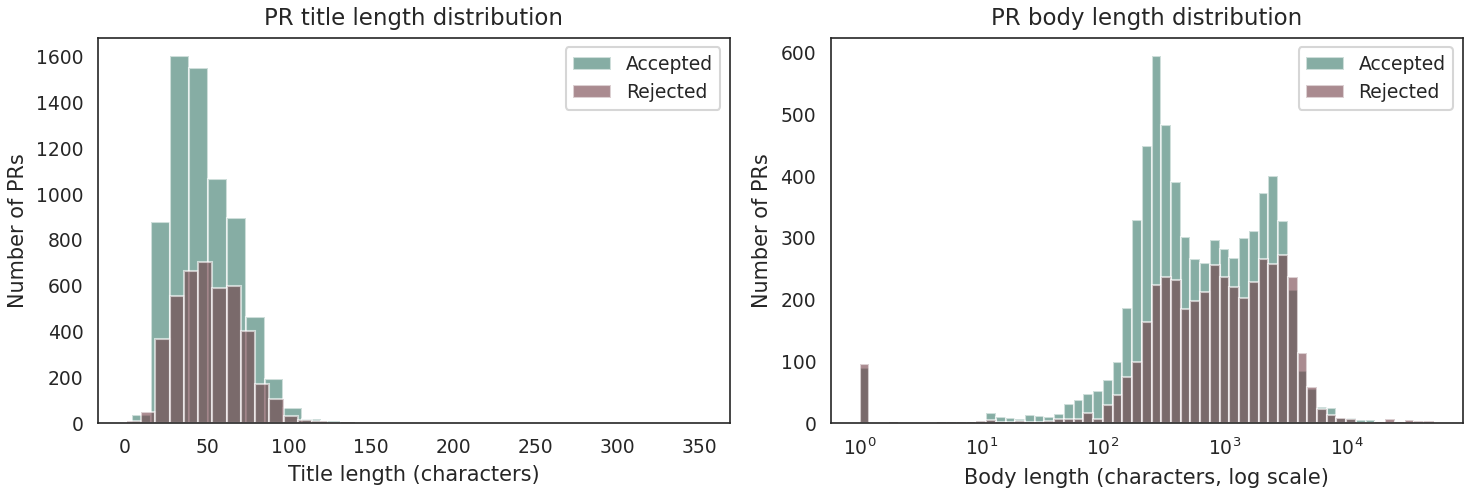

In [21]:
# PR title and body length distributions

pre_filter_pop['title_length'] = pre_filter_pop['title'].fillna('').str.len()
pre_filter_pop['body_length']  = pre_filter_pop['body'].fillna('').str.len()
pre_filter_pop['has_body']     = (
    pre_filter_pop['body'].notna() & (pre_filter_pop['body'].str.len() > 0)
)

body_bins = np.logspace(
    np.log10(max(pre_filter_pop["body_length"].clip(lower=1).min(), 1)),
    np.log10(pre_filter_pop["body_length"].clip(lower=1).max()),
    60
)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

for is_rej, label_name, color in [
    (False, "Accepted", COLOR_ACCEPTED),
    (True,  "Rejected", COLOR_REJECTED),
]:
    subset = pre_filter_pop[pre_filter_pop["is_rejected"] == is_rej]
    axes[0].hist(subset["title_length"], bins=30, alpha=0.6, color=color, label=label_name)
    axes[1].hist(subset["body_length"].clip(lower=1), bins=body_bins, alpha=0.6,
                 color=color, label=label_name)

axes[0].set_title("PR title length distribution")
axes[0].set_xlabel("Title length (characters)")
axes[0].set_ylabel("Number of PRs")
axes[0].legend()

axes[1].set_xscale("log")
axes[1].set_title("PR body length distribution")
axes[1].set_xlabel("Body length (characters, log scale)")
axes[1].set_ylabel("Number of PRs")
axes[1].legend()

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig_p1_text_lengths.pdf"))
plt.show()

### Code Diff Analysis

In [22]:
# Compute per-PR diff statistics; build diff_with_outcome and bin_stats

# Per-PR totals from commit details
pr_diff_stats = (
    pr_commit_details_df_f
    .groupby("pr_id", as_index=False)
    .agg(
        total_additions=("additions", "sum"),
        total_deletions=("deletions", "sum"),
    )
)
pr_diff_stats["total_changes"]      = pr_diff_stats["total_additions"] + pr_diff_stats["total_deletions"]
pr_diff_stats["total_lines_changed"] = pr_diff_stats["total_changes"]

# Merge with closed PRs to attach is_rejected; inner join drops PRs with no diff data
diff_with_outcome = (
    eda_pr_closed_df[["id", "is_rejected"]]
    .merge(pr_diff_stats, left_on="id", right_on="pr_id", how="inner")
)

# Diff Bin stats
bins       = [0, 50, 100, 250, 500, 1000, float("inf")]
bin_labels = ["≤50", "51–100", "101–250", "251–500", "501–1000", ">1000"]

pr_closed_with_diff = eda_pr_closed_df.merge(
    pr_diff_stats, left_on="id", right_on="pr_id", how="left"
)
pr_closed_with_diff["total_changes"] = pr_closed_with_diff["total_changes"].fillna(0)
pr_closed_with_diff["diff_bucket"]   = pd.cut(
    pr_closed_with_diff["total_changes"],
    bins=bins,
    labels=bin_labels,
    include_lowest=True,
)

bin_stats = (
    pr_closed_with_diff
    .groupby("diff_bucket", observed=True)["is_rejected"]
    .agg(total="count", rejected="sum")
    .reset_index()
)
bin_stats["accepted"]       = bin_stats["total"] - bin_stats["rejected"]
bin_stats["rejection_rate"] = bin_stats["rejected"] / bin_stats["total"]

print(f"pr_diff_stats:     {len(pr_diff_stats):,} PRs with diff data")
print(f"diff_with_outcome: {len(diff_with_outcome):,} closed PRs with diff data")
print(f"bin_stats rows:    {len(bin_stats)}")

pr_diff_stats:     12,359 PRs with diff data
diff_with_outcome: 11,034 closed PRs with diff data
bin_stats rows:    6


Diff size descriptive statistics (total lines changed):
  count  :       11,034
  mean   :      2,584.6
  std    :     20,013.6
  min    :            0
  p25    :           22
  p50    :          108
  p75    :          508
  p95    :        9,479
  p99    :       47,155
  max    :    1,451,946


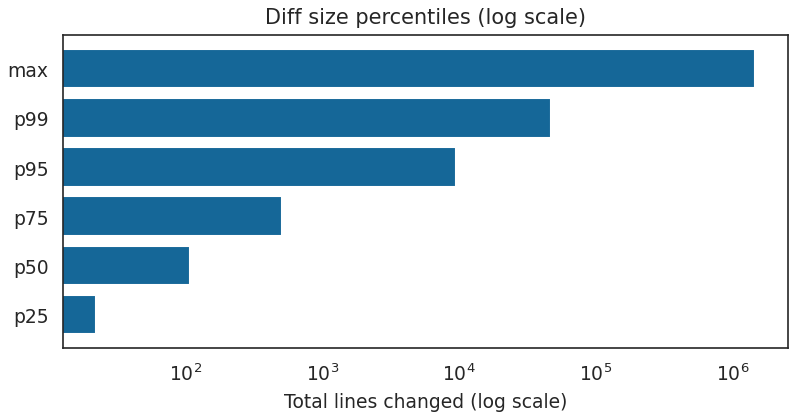

In [23]:
# Diff size descriptive statistics
# Population: pre_filter_pop — 11,048 PRs (before diff-size and filtering)

OUT_DIR = DRIVE_BASE / 'results' / 'final' / 'eda'
os.makedirs(OUT_DIR, exist_ok=True)

desc = diff_with_outcome["total_lines_changed"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.95, 0.99]
)

print("Diff size descriptive statistics (total lines changed):")
print(f"  count  : {int(desc['count']):>12,}")
print(f"  mean   : {desc['mean']:>12,.1f}")
print(f"  std    : {desc['std']:>12,.1f}")
print(f"  min    : {desc['min']:>12,.0f}")
print(f"  p25    : {desc['25%']:>12,.0f}")
print(f"  p50    : {desc['50%']:>12,.0f}")
print(f"  p75    : {desc['75%']:>12,.0f}")
print(f"  p95    : {desc['95%']:>12,.0f}")
print(f"  p99    : {desc['99%']:>12,.0f}")
print(f"  max    : {desc['max']:>12,.0f}")

pct_labels = ["p25", "p50", "p75", "p95", "p99", "max"]
pct_values = [desc["25%"], desc["50%"], desc["75%"], desc["95%"], desc["99%"], desc["max"]]

fig, ax = plt.subplots(figsize=(5.5, 3.0))
ax.barh(pct_labels, pct_values)
ax.set_xscale("log")
ax.set_title("Diff size percentiles (log scale)")
ax.set_xlabel("Total lines changed (log scale)")
ax.title.set_fontsize(10)
ax.xaxis.label.set_fontsize(9)
ax.yaxis.label.set_fontsize(9)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig_p1_diff_size_pcts.pdf"))
plt.show()

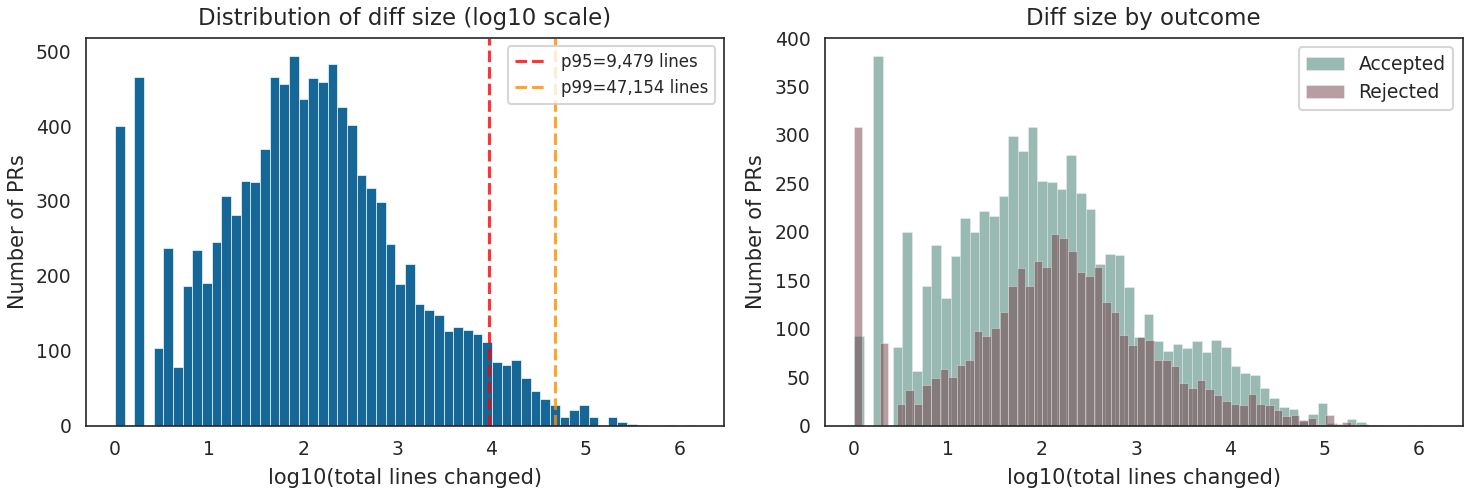

In [24]:
# Log-scale histogram of diff sizes by outcome
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

vals = diff_with_outcome["total_lines_changed"].clip(lower=1)

# Overall distribution on log10 axis
axes[0].hist(np.log10(vals), bins=60, edgecolor="white", linewidth=0.3)
for pct, lbl, col in [(95, "p95", "red"), (99, "p99", "darkorange")]:
    v = np.percentile(vals, pct)
    axes[0].axvline(np.log10(v), color=col, linestyle="--", alpha=0.8,
                    label=f"{lbl}={int(v):,} lines")
axes[0].set_xlabel("log10(total lines changed)")
axes[0].set_ylabel("Number of PRs")
axes[0].set_title("Distribution of diff size (log10 scale)")
axes[0].legend(fontsize=8)

# Rejected vs accepted
for is_rej, label_name, color in [
    (False, "Accepted", COLOR_ACCEPTED),
    (True,  "Rejected", COLOR_REJECTED),
]:
    subset = diff_with_outcome[diff_with_outcome["is_rejected"] == is_rej]
    v = subset["total_lines_changed"].clip(lower=1)
    axes[1].hist(np.log10(v), bins=60, alpha=0.5, color=color,
                 label=label_name, edgecolor="white", linewidth=0.3)
axes[1].set_xlabel("log10(total lines changed)")
axes[1].set_ylabel("Number of PRs")
axes[1].set_title("Diff size by outcome")
axes[1].legend()

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig_diff_size_distribution.pdf"))
plt.show()

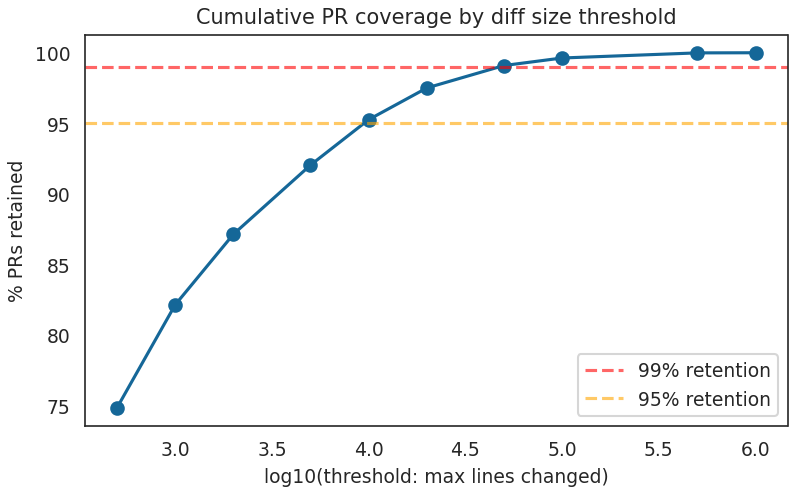


Coverage table:
 threshold  retained  pct_retained  removed  rejection_rate_removed
       500      8256     74.823274     2778                0.410367
      1000      9062     82.127968     1972                0.403144
      2000      9614     87.130687     1420                0.373944
      5000     10154     92.024651      880                0.348864
     10000     10510     95.251042      524                0.366412
     20000     10758     97.498641      276                0.405797
     50000     10933     99.084647      101                0.376238
    100000     10992     99.619358       42                0.476190
    500000     11032     99.981874        2                0.000000
   1000000     11033     99.990937        1                0.000000


In [25]:
# Cumulative coverage curve by line threshold
thresholds = [500, 1000, 2000, 5000, 10000, 20000, 50000, 100000, 500000, 1_000_000]
total_prs  = len(diff_with_outcome)

rows = []
for t in thresholds:
    retained   = (diff_with_outcome["total_lines_changed"] <= t).sum()
    removed    = total_prs - retained
    rej_removed = (
        diff_with_outcome[diff_with_outcome["total_lines_changed"] > t]["is_rejected"].mean()
        if removed > 0 else float("nan")
    )
    rows.append({
        "threshold":             t,
        "retained":              retained,
        "pct_retained":          retained / total_prs * 100,
        "removed":               removed,
        "rejection_rate_removed": rej_removed,
    })

coverage_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(np.log10(coverage_df["threshold"]), coverage_df["pct_retained"], marker="o")
ax.axhline(99, color="red",    linestyle="--", alpha=0.6, label="99% retention")
ax.axhline(95, color="orange", linestyle="--", alpha=0.6, label="95% retention")
ax.set_xlabel("log10(threshold: max lines changed)")
ax.set_ylabel("% PRs retained")
ax.set_title("Cumulative PR coverage by diff size threshold")
ax.legend()
ax.title.set_fontsize(10)
ax.xaxis.label.set_fontsize(9)
ax.yaxis.label.set_fontsize(9)
plt.tight_layout()

fig.savefig(os.path.join(OUT_DIR, "fig_p1_coverage_curve.pdf"))
plt.show()

print("\nCoverage table:")
print(coverage_df.to_string(index=False))

Threshold: 50,000 lines
Outlier PRs above threshold: 101


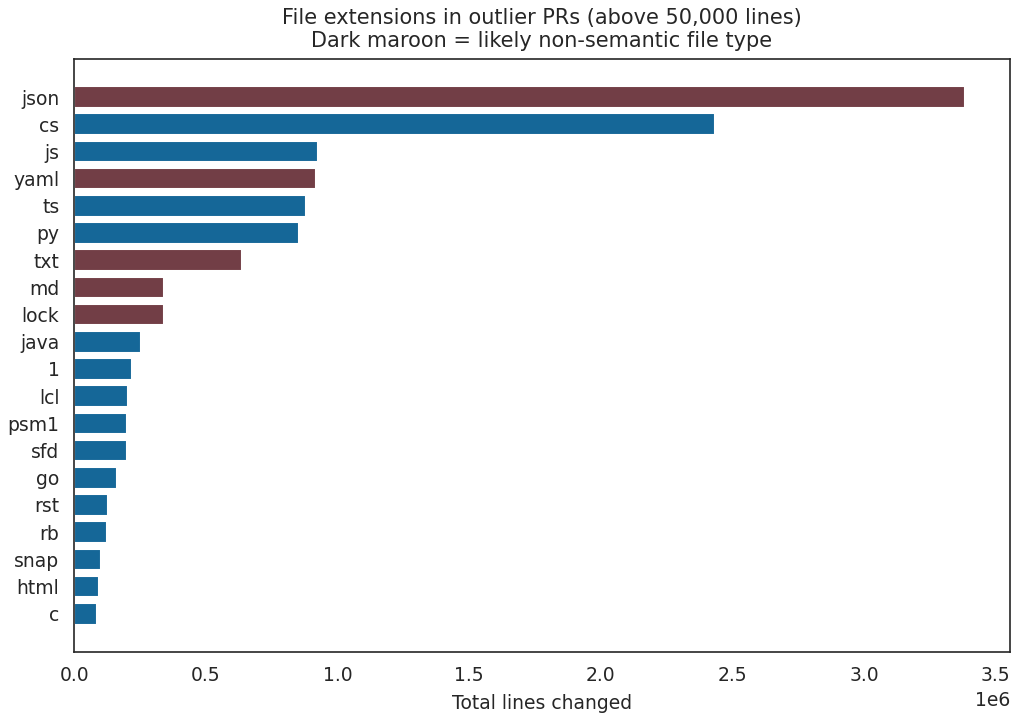


Top extensions in outlier PRs:
           total_lines  n_files  likely_non_code
extension                                       
json         3383837.0     3734             True
cs           2433459.0     2350            False
js            925064.0     1922            False
yaml          918917.0     2389             True
ts            879805.0     4155            False
py            853315.0     4158            False
txt           636454.0      235             True
md            342562.0     5848             True
lock          341763.0      435             True
java          252374.0     3191            False
1             219102.0        2            False
lcl           204470.0      124            False
psm1          202649.0     1080            False
sfd           201504.0        8            False
go            164180.0      643            False
rst           127581.0      294            False
rb            125919.0     1448            False
snap          102285.0      105      

In [26]:
# File extension analysis for outlier PRs
# Shows which file extensions dominate PRs above the 50,000-line threshold.

p99_threshold = 50000
outlier_pr_ids = set(
    diff_with_outcome[diff_with_outcome["total_lines_changed"] > p99_threshold]["pr_id"]
)

print(f"Threshold: {int(p99_threshold):,} lines")
print(f"Outlier PRs above threshold: {len(outlier_pr_ids)}")

outlier_files = pr_commit_details_df_f[
    pr_commit_details_df_f["pr_id"].isin(outlier_pr_ids)
].copy()

outlier_files["extension"] = (
    outlier_files["filename"]
    .fillna("")
    .str.rsplit(".", n=1)
    .str[-1]
    .str.lower()
    .replace("", "no_ext")
)

ext_stats = (
    outlier_files
    .assign(lines_changed=lambda d: d["additions"] + d["deletions"])
    .groupby("extension")
    .agg(total_lines=("lines_changed", "sum"), n_files=("filename", "count"))
    .sort_values("total_lines", ascending=False)
    .head(20)
)

non_code_exts = {
    "lock", "json", "yaml", "yml", "toml", "txt", "md",
    "csv", "svg", "png", "jpg", "gif", "ico", "min",
}
ext_stats["likely_non_code"] = ext_stats.index.isin(non_code_exts)

bar_colors = [COLOR_REJECTED if v else CATEGORICAL_PALETTE[0]
              for v in ext_stats["likely_non_code"]]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(ext_stats.index, ext_stats["total_lines"], color=bar_colors)
ax.set_xlabel("Total lines changed")
ax.set_title(
    f"File extensions in outlier PRs (above {int(p99_threshold):,} lines)\n"
    "Dark maroon = likely non-semantic file type"
)
ax.invert_yaxis()
ax.title.set_fontsize(10)
ax.xaxis.label.set_fontsize(9)
ax.yaxis.label.set_fontsize(9)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig_p1_outlier_extensions.pdf"))
plt.show()

print("\nTop extensions in outlier PRs:")
print(ext_stats.to_string())


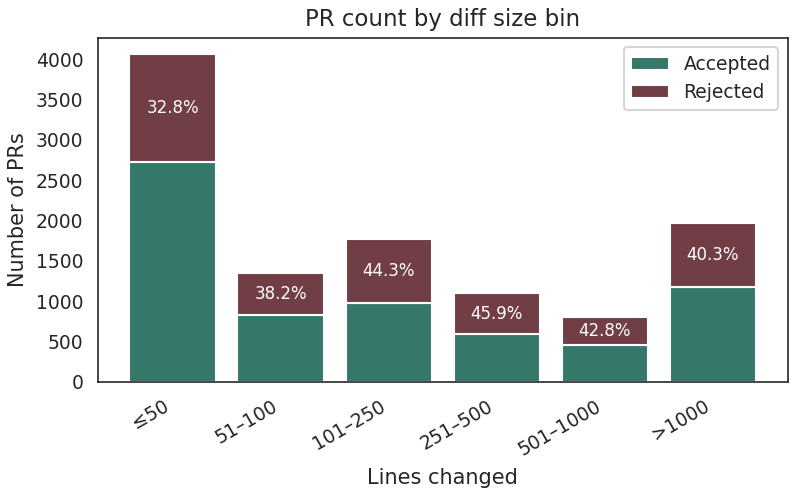

In [27]:
# Rejection rate by diff size bin

bin_labels     = bin_stats["diff_bucket"].astype(str).tolist()
accepted_counts = bin_stats["accepted"].tolist()
rejected_counts = bin_stats["rejected"].tolist()
rejection_rates = bin_stats["rejection_rate"].tolist()

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.bar(bin_labels, accepted_counts, color=COLOR_ACCEPTED, label="Accepted")
bars_rej = ax.bar(bin_labels, rejected_counts, bottom=accepted_counts,
                  color=COLOR_REJECTED, label="Rejected")

for bar, acc, rate in zip(bars_rej, accepted_counts, rejection_rates):
    bar_x = bar.get_x() + bar.get_width() / 2
    bar_y = acc + bar.get_height() / 2
    ax.text(bar_x, bar_y, f"{rate:.1%}",
            ha="center", va="center", fontsize=8, color="white")

ax.legend()
ax.set_title("PR count by diff size bin")
ax.set_xlabel("Lines changed")
ax.set_ylabel("Number of PRs")
ax.tick_params(axis="x", labelrotation=30)
plt.setp(ax.get_xticklabels(), ha="right")

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig_p1_rejection_rate_by_bin.pdf"))
plt.show()

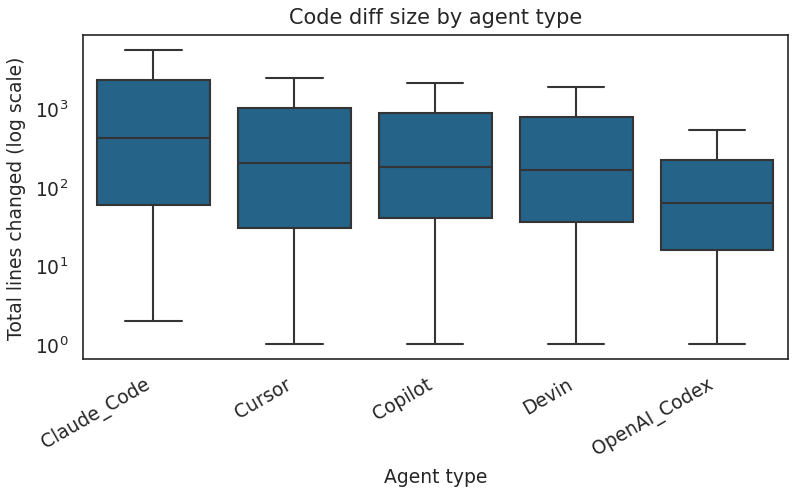

In [28]:
# Code diff size by agent type

diff_agg_agent = diff_with_outcome.merge(
    pr_df_f[["id", "agent"]].rename(columns={"id": "pr_id"}),
    on="pr_id",
    how="inner",
)
diff_agg_agent = diff_agg_agent[diff_agg_agent["total_lines_changed"] > 0]

agent_order = (
    diff_agg_agent.groupby("agent")["total_lines_changed"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(5.5, 3.5))
sns.boxplot(
    data=diff_agg_agent,
    x="agent", y="total_lines_changed",
    order=agent_order,
    color=CATEGORICAL_PALETTE[0],
    showfliers=False,
    ax=ax,
)
ax.set_yscale("log")
ax.set_title("Code diff size by agent type")
ax.set_xlabel("Agent type")
ax.set_ylabel("Total lines changed (log scale)")
ax.title.set_fontsize(10)
ax.xaxis.label.set_fontsize(9)
ax.yaxis.label.set_fontsize(9)
ax.tick_params(axis="x", labelrotation=30)
plt.setp(ax.get_xticklabels(), ha="right")

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig_p1_diff_size_by_agent.pdf"))
plt.show()


In [29]:
# Identify PRs with no commit details (Type A PRs)
# Shows the 14 closed PRs in pre_filter_pop that have no rows in pr_commit_details_df_f,
# explaining the drop from 11,048 to 11,034 when diff statistics are computed later.

pr_ids_in_details_f = set(pr_commit_details_df_f['pr_id'].unique())
no_details_df       = eda_pr_closed_df[~eda_pr_closed_df['id'].isin(pr_ids_in_details_f)].copy()

n_no_details      = len(no_details_df)
n_with_details    = len(eda_pr_closed_df) - n_no_details
rej_no_details    = no_details_df['is_rejected'].mean()
acc_no_details    = int((~no_details_df['is_rejected']).sum())
rej_count_no_det  = int(no_details_df['is_rejected'].sum())

print(f"Closed PRs (pre_filter_pop):  {len(eda_pr_closed_df):,}")
print(f"  With commit details:        {n_with_details:,}")
print(f"  With NO commit details:     {n_no_details:,}")
print()
print(f"Rejection rate among no-detail PRs:  {rej_no_details:.3f}")
print(f"  Accepted: {acc_no_details:,}  |  Rejected: {rej_count_no_det:,}")
print()
print(no_details_df[['id', 'is_rejected']].to_string(index=False))

Closed PRs (pre_filter_pop):  11,048
  With commit details:        11,034
  With NO commit details:     14

Rejection rate among no-detail PRs:  1.000
  Accepted: 0  |  Rejected: 14

        id  is_rejected
3131184648         True
3078834752         True
3081557962         True
3245800483         True
3131643166         True
3136806866         True
3183768167         True
3193244780         True
3254809770         True
2759847657         True
2769964943         True
3197065453         True
2834803615         True
3112311086         True


**Finding:** There are 14 PRs with 0 commit details. Hence, the result of the diff statistics is a count of 11034 PRs (instead of 11048 PRs).

Category                         Count   Rej. rate
----------------------------------------------------
Has usable diff                 10,749       0.371
Type A (absent from details)        14       1.000
Type B (all patches null)          285       0.961

Non-parseable diffs: 299 PRs (2.7% of pre_filter_pop)
  Type A (absent from commit_details):  14
  Type B (all patches null or empty):   285


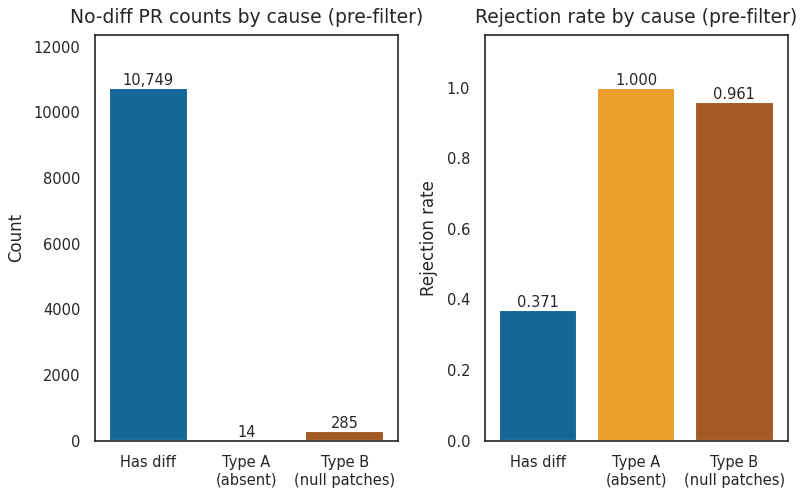

In [30]:
# No-diff PR analysis; non-parseable count; breakdown chart

# Type A / Type B classifications of non-valid code diffs
pr_ids_in_details_nodiff = set(pr_commit_details_df_f['pr_id'].unique())

_has_content_nodiff = (
    pr_commit_details_df_f["patch"].notna()
    & (pr_commit_details_df_f["patch"].str.strip() != "")
)
pr_ids_with_content_nodiff = set(
    pr_commit_details_df_f.loc[_has_content_nodiff, "pr_id"].unique()
)

type_a_ids = set(eda_pr_closed_df['id']) - pr_ids_in_details_nodiff
type_b_ids = (pr_ids_in_details_nodiff - pr_ids_with_content_nodiff) \
             & set(eda_pr_closed_df['id'])

n_type_a = len(type_a_ids)   # Absent from pr_commit_details
n_type_b = len(type_b_ids)   # Null patches or non-parseable diffs
n_has    = len(eda_pr_closed_df) - n_type_a - n_type_b

rej_a   = (eda_pr_closed_df[eda_pr_closed_df['id'].isin(type_a_ids)]['is_rejected'].mean()
           if n_type_a else float('nan'))
rej_b   = (eda_pr_closed_df[eda_pr_closed_df['id'].isin(type_b_ids)]['is_rejected'].mean()
           if n_type_b else float('nan'))
rej_has  = eda_pr_closed_df[eda_pr_closed_df['id'].isin(pr_ids_with_content_nodiff)]['is_rejected'].mean()
overall_r = eda_pr_closed_df['is_rejected'].mean()

print(f"{'Category':<30} {'Count':>7}  {'Rej. rate':>10}")
print('-' * 52)
print(f"{'Has usable diff':<30} {n_has:>7,}  {rej_has:>10.3f}")
print(f"{'Type A (absent from details)':<30} {n_type_a:>7,}  {rej_a:>10.3f}")
print(f"{'Type B (all patches null)':<30} {n_type_b:>7,}  {rej_b:>10.3f}")

# Non-parseable summary (P1-5, merged)
n_nonparseable   = n_type_a + n_type_b
pct_nonparseable = 100 * n_nonparseable / len(pre_filter_pop)
print()
print(f"Non-parseable diffs: {n_nonparseable:,} PRs ({pct_nonparseable:.1f}% of pre_filter_pop)")
print(f"  Type A (absent from commit_details):  {n_type_a:,}")
print(f"  Type B (all patches null or empty):   {n_type_b:,}")

# Breakdown chart (P1-6)
categories = ['Has diff', 'Type A\n(absent)', 'Type B\n(null patches)']
counts_nd  = [n_has, n_type_a, n_type_b]
rates_nd   = [rej_has, rej_a, rej_b]

fig, axes = plt.subplots(1, 2, figsize=(5.5, 3.5))

bars0 = axes[0].bar(categories, counts_nd, color=CATEGORICAL_PALETTE[:3])
axes[0].bar_label(bars0, fmt="{:,.0f}", fontsize=7)
axes[0].set_ylabel("Count")
axes[0].set_title("No-diff PR counts by cause (pre-filter)")
axes[0].set_ylim(0, max(counts_nd) * 1.15)

bars1 = axes[1].bar(categories, rates_nd, color=CATEGORICAL_PALETTE[:3])
axes[1].bar_label(bars1, fmt="{:.3f}", fontsize=7)
axes[1].set_ylabel("Rejection rate")
axes[1].set_title("Rejection rate by cause (pre-filter)")
axes[1].set_ylim(0, 1.15)

for ax in axes:
    ax.title.set_fontsize(9)
    ax.xaxis.label.set_fontsize(8)
    ax.yaxis.label.set_fontsize(8)
    ax.tick_params(axis='both', labelsize=7)

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig_p1_nonparseable.pdf"))
plt.show()

## Part 2 — Temporal Split Strategy (70/15/15)
This section analyzes the train, validation, and test splits of the final study population of 10,648 PRs (Section 4.2.3 of the Thesis).

In [31]:
# Final study population (three filters applied - code diff 50k outliers, Type A and Type B PRs)

# Remove 285 PRs with diffs more than 50k changes lines
CHOSEN_THRESHOLD    = 50000
oversized_ids       = set(
    diff_with_outcome[diff_with_outcome['total_lines_changed'] > CHOSEN_THRESHOLD]['pr_id']
)
pr_ids_with_commits = set(pr_commits_df_f['pr_id'].unique())

pr_ids_in_details = set(pr_commit_details_df_f['pr_id'].unique())

# Remove 14 PRs (Type A)
type_a_mask = (
    (~eda_pr_closed_df['id'].isin(pr_ids_in_details))
    & (~eda_pr_closed_df['id'].isin(pr_ids_with_commits))
)

# Remove 285 PRs (Type B)
has_content = (
    pr_commit_details_df_f["patch"].notna()
    & (pr_commit_details_df_f["patch"].str.strip() != "")
)
pr_ids_with_content = set(pr_commit_details_df_f.loc[has_content, "pr_id"].unique())

final_pop = eda_pr_closed_df[
    ~type_a_mask
    & ~eda_pr_closed_df['id'].isin(oversized_ids)
    & eda_pr_closed_df['id'].isin(pr_ids_with_content)
].copy()
final_pop['label'] = final_pop['is_rejected'].astype(int)

assert len(pre_filter_pop) == 11048, f"Expected 11048, got {len(pre_filter_pop)}"
assert len(final_pop) == 10648,      f"Expected 10648, got {len(final_pop)}"

OVERALL_REJECTION_RATE = final_pop["label"].mean()

print(f"Final study population: {len(final_pop):,} PRs")
print(f"  Rejection rate:       {OVERALL_REJECTION_RATE:.3f}")

Final study population: 10,648 PRs
  Rejection rate:       0.371


Percentile-based temporal split on final_pop:
Split        N      %  Date range                                Rej. rate
--------------------------------------------------------------------------------
Train    7,453  70.0%  2024-12-24 to 2025-06-30                  0.383
Val      1,597  15.0%  2025-06-30 to 2025-07-13                  0.331
Test     1,598  15.0%  2025-07-13 to 2025-07-30                  0.352

Train/val boundary: 2025-06-30  (70th-percentile PR)
Val/test boundary : 2025-07-13  (85th-percentile PR)


/tmp/ipykernel_2342/3948737695.py:40: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(month=pr_sorted["created_at"].dt.to_period("M"))
/tmp/ipykernel_2342/3948737695.py:61: UserWarning: Converting to Period representation will drop timezone information.
  cutoff_month = cutoff.to_period("M").strftime("%Y-%m")


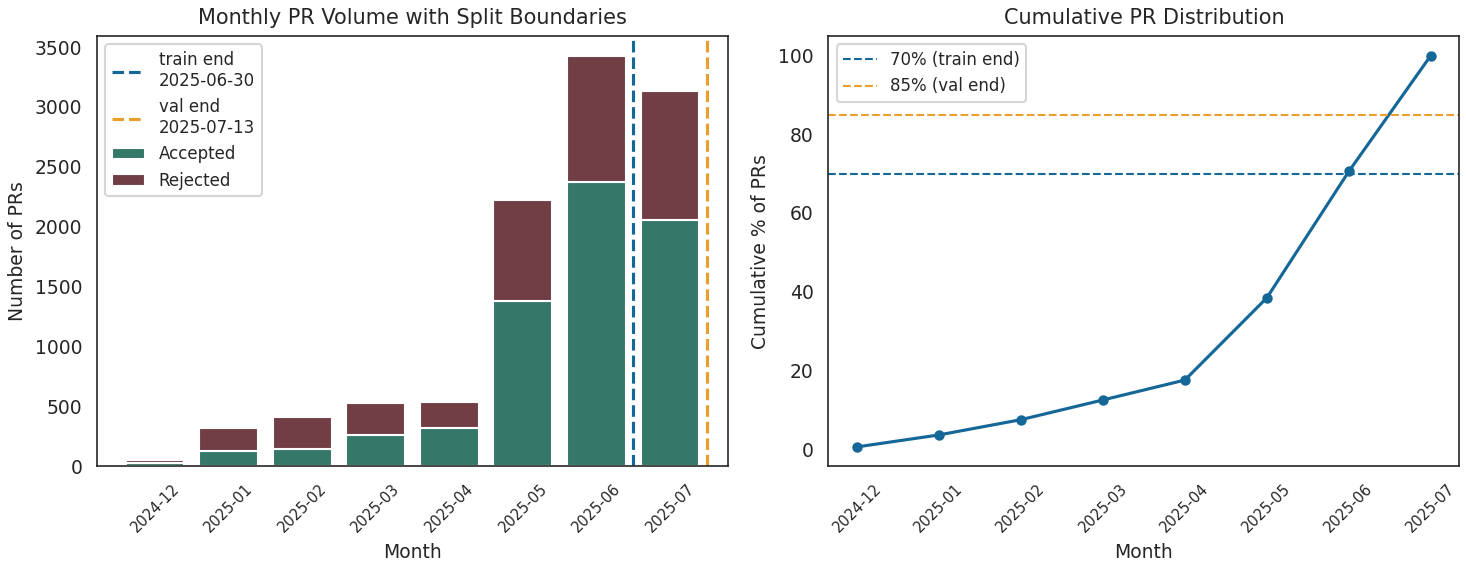

In [32]:
# Temporal split validation (70/15/15)
# Splits final_pop using a percentile-based cut on creation date.
# Matches src/splits.py. Produces train_pr, val_pr, test_pr.

pr_sorted = final_pop.sort_values("created_at").reset_index(drop=True)
n_total   = len(pr_sorted)

train_end_idx = int(n_total * 0.70)
val_end_idx   = int(n_total * 0.85)

train_pr = pr_sorted.iloc[:train_end_idx].copy()
val_pr   = pr_sorted.iloc[train_end_idx:val_end_idx].copy()
test_pr  = pr_sorted.iloc[val_end_idx:].copy()

train_ids = set(train_pr['id'])
val_ids   = set(val_pr['id'])
final_pop['split'] = final_pop['id'].apply(
    lambda x: 'Train' if x in train_ids else ('Val' if x in val_ids else 'Test')
)

train_cutoff = train_pr["created_at"].max()
val_cutoff   = val_pr["created_at"].max()

print("Percentile-based temporal split on final_pop:")
print(f"{'Split':<6}  {'N':>6}  {'%':>5}  {'Date range':<40}  Rej. rate")
print("-" * 80)
for name, split in [("Train", train_pr), ("Val", val_pr), ("Test", test_pr)]:
    pct = len(split) / n_total * 100
    dr  = f"{split['created_at'].min().date()} to {split['created_at'].max().date()}"
    rr  = split["label"].mean()
    print(f"{name:<6}  {len(split):>6,}  {pct:>4.1f}%  {dr:<40}  {rr:.3f}")

print()
print(f"Train/val boundary: {train_cutoff.date()}  (70th-percentile PR)")
print(f"Val/test boundary : {val_cutoff.date()}  (85th-percentile PR)")

# Monthly distribution with split boundaries
monthly_sorted = (
    pr_sorted
    .assign(month=pr_sorted["created_at"].dt.to_period("M"))
    .groupby(["month", "label"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
monthly_sorted.columns = ["month", "accepted", "rejected"]
monthly_sorted["total"] = monthly_sorted["accepted"] + monthly_sorted["rejected"]
monthly_sorted["cumulative_pct"] = monthly_sorted["total"].cumsum() / n_total * 100
month_labels = monthly_sorted["month"].astype(str).tolist()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Monthly volume with split boundaries (accepted bottom, rejected on top)
axes[0].bar(month_labels, monthly_sorted["accepted"], label="Accepted", color=COLOR_ACCEPTED)
axes[0].bar(month_labels, monthly_sorted["rejected"], bottom=monthly_sorted["accepted"],
            label="Rejected", color=COLOR_REJECTED)
for cutoff, label, color in [
    (train_cutoff, f"train end\n{train_cutoff.date()}", CATEGORICAL_PALETTE[0]),
    (val_cutoff,   f"val end\n{val_cutoff.date()}",     CATEGORICAL_PALETTE[1]),
]:
    cutoff_month = cutoff.to_period("M").strftime("%Y-%m")
    if cutoff_month in month_labels:
        x_pos = month_labels.index(cutoff_month)
        axes[0].axvline(x=x_pos + 0.5, color=color, linestyle="--", linewidth=1.5, label=label)
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Number of PRs")
axes[0].set_title("Monthly PR Volume with Split Boundaries")
axes[0].legend(fontsize=8)
axes[0].tick_params(axis="x", labelrotation=45, labelsize=7)
axes[0].title.set_fontsize(10)
axes[0].xaxis.label.set_fontsize(9)
axes[0].yaxis.label.set_fontsize(9)

# Cumulative curve with split boundaries
axes[1].plot(month_labels, monthly_sorted["cumulative_pct"], marker="o", markersize=4)
axes[1].axhline(70, color=CATEGORICAL_PALETTE[0], linestyle="--", linewidth=1, label="70% (train end)")
axes[1].axhline(85, color=CATEGORICAL_PALETTE[1], linestyle="--", linewidth=1, label="85% (val end)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Cumulative % of PRs")
axes[1].set_title("Cumulative PR Distribution")
axes[1].legend(fontsize=8)
axes[1].tick_params(axis="x", labelrotation=45, labelsize=7)
axes[1].title.set_fontsize(10)
axes[1].xaxis.label.set_fontsize(9)
axes[1].yaxis.label.set_fontsize(9)

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig_p2_temporal_split.pdf"))
plt.show()

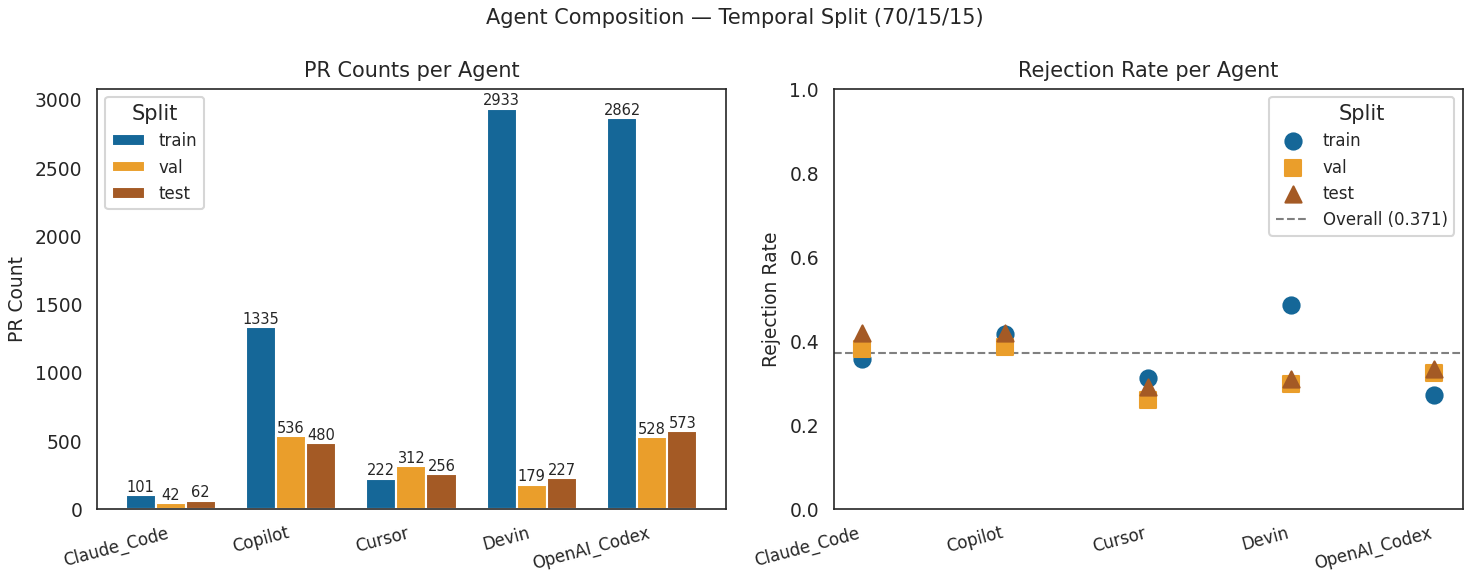


PR Counts per Agent per Split:
split         test  train  val
agent                         
Claude_Code     62    101   42
Copilot        480   1335  536
Cursor         256    222  312
Devin          227   2933  179
OpenAI_Codex   573   2862  528


In [33]:
# Agent composition: PR counts and rejection rate by agent per split
# Shows how agents are distributed across train/val/test and whether rejection
# rates are stable, validating that the temporal split does not introduce
# agent-level representation bias.

splits_dict = {'train': train_pr, 'val': val_pr, 'test': test_pr}
agents      = sorted(final_pop['agent'].dropna().unique())

records = []
for split_name, split_df in splits_dict.items():
    for ag in agents:
        sub = split_df[split_df['agent'] == ag]
        records.append({
            'split':          split_name,
            'agent':          ag,
            'n':              len(sub),
            'rejection_rate': sub['label'].mean() if len(sub) else float('nan'),
        })
comp_df = pd.DataFrame(records)

split_colors  = {'train': CATEGORICAL_PALETTE[0], 'val': CATEGORICAL_PALETTE[1],
                 'test':  CATEGORICAL_PALETTE[2]}
split_markers = {'train': 'o', 'val': 's', 'test': '^'}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Agent Composition — Temporal Split (70/15/15)', fontsize=10)

x     = np.arange(len(agents))
width = 0.25

for i, split_name in enumerate(['train', 'val', 'test']):
    sub  = comp_df[comp_df['split'] == split_name].set_index('agent').reindex(agents)
    ns   = sub['n'].fillna(0).astype(int).values
    bars = axes[0].bar(x + (i - 1) * width, ns, width,
                       label=split_name, color=split_colors[split_name])
    for bar, n in zip(bars, ns):
        if n > 0:
            axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                         str(n), ha='center', va='bottom', fontsize=7)

axes[0].set_xticks(x)
axes[0].set_xticklabels(agents, rotation=15, ha='right', fontsize=8)
axes[0].set_ylabel('PR Count')
axes[0].set_title('PR Counts per Agent')
axes[0].legend(title='Split', fontsize=8)
axes[0].title.set_fontsize(10)
axes[0].yaxis.label.set_fontsize(9)

for split_name in ['train', 'val', 'test']:
    sub   = comp_df[comp_df['split'] == split_name].set_index('agent').reindex(agents)
    rates = sub['rejection_rate'].values
    axes[1].scatter(x, rates, marker=split_markers[split_name],
                    color=split_colors[split_name], label=split_name, s=60, zorder=3)

axes[1].axhline(OVERALL_REJECTION_RATE, color='grey', linestyle='--', linewidth=1,
                label=f'Overall ({OVERALL_REJECTION_RATE:.3f})')
axes[1].set_xticks(x)
axes[1].set_xticklabels(agents, rotation=15, ha='right', fontsize=8)
axes[1].set_ylabel('Rejection Rate')
axes[1].set_title('Rejection Rate per Agent')
axes[1].set_ylim(0, 1)
axes[1].legend(title='Split', fontsize=8)
axes[1].title.set_fontsize(10)
axes[1].yaxis.label.set_fontsize(9)

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig_p2_agent_composition.pdf"))
plt.show()

print('\nPR Counts per Agent per Split:')
print(comp_df.pivot_table(index='agent', columns='split', values='n',
                          fill_value=0).astype(int).to_string())

## Part 3 — Exploratory Data Analysis (10,648 PRs, final study population)
This section discusses the exploratory data analyses done on the final study population of 10,648 PRs (Section 4.3 of the Thesis).

### Class Distribution

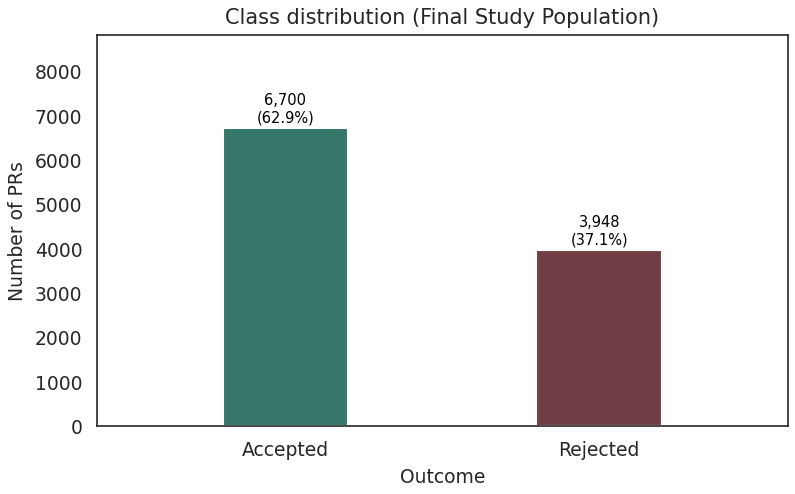

In [34]:
# Class Distribution of the 10,648 PRs

n_acc_fp = int((final_pop["label"] == 0).sum())
n_rej_fp = int((final_pop["label"] == 1).sum())

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.bar(["Accepted", "Rejected"], [n_acc_fp, n_rej_fp],
       width=0.4, color=[COLOR_ACCEPTED, COLOR_REJECTED])
ax.text(0, n_acc_fp + CLASS_DIST_YLIM * 0.01,
        f"{n_acc_fp:,}\n({n_acc_fp/len(final_pop)*100:.1f}%)",
        ha="center", va="bottom", fontsize=7, color="black")
ax.text(1, n_rej_fp + CLASS_DIST_YLIM * 0.01,
        f"{n_rej_fp:,}\n({n_rej_fp/len(final_pop)*100:.1f}%)",
        ha="center", va="bottom", fontsize=7, color="black")
ax.set_xlim(-0.6, 1.6)
ax.set_ylim(0, CLASS_DIST_YLIM)
ax.set_title("Class distribution (Final Study Population)")
ax.set_xlabel("Outcome")
ax.set_ylabel("Number of PRs")
ax.title.set_fontsize(10)
ax.xaxis.label.set_fontsize(9)
ax.yaxis.label.set_fontsize(9)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig_p3_class_distribution.pdf"))
plt.show()

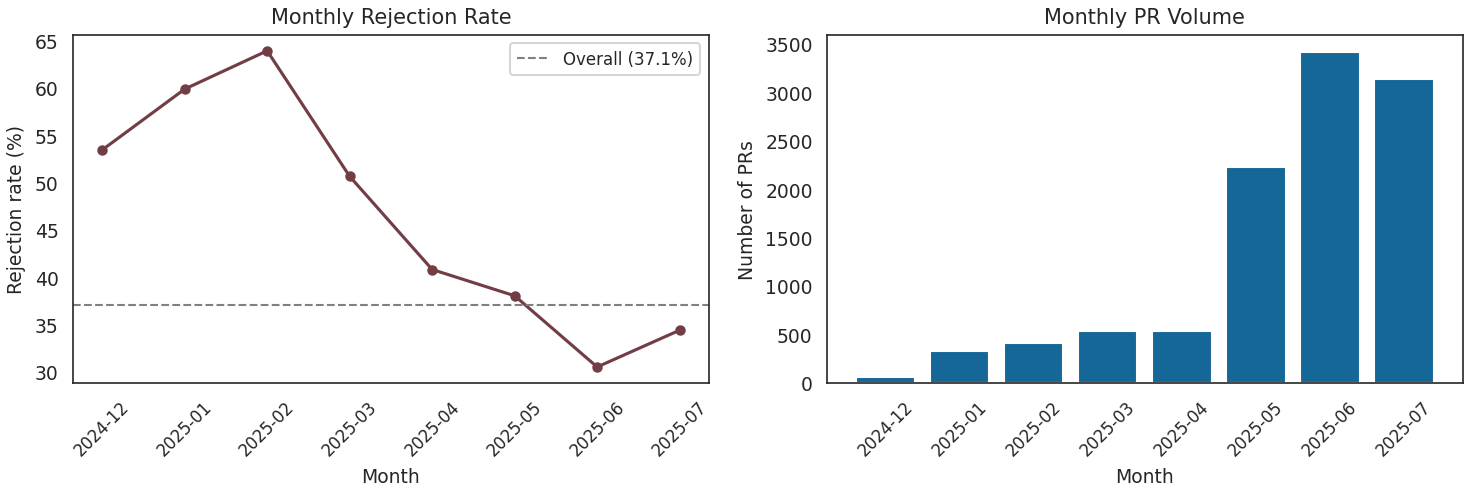

Overall rejection rate (final_pop): 37.1%
  month  rejected  total     rate
2024-12        31     58 0.534483
2025-01       194    324 0.598765
2025-02       264    413 0.639225
2025-03       270    533 0.506567
2025-04       220    539 0.408163
2025-05       846   2224 0.380396
2025-06      1044   3421 0.305174
2025-07      1079   3136 0.344069


In [35]:
# Monthly rejection rate and PR volume (final study population)

monthly_fp = (
    final_pop
    .groupby('month')['is_rejected']
    .agg(rejected='sum', total='count')
    .reset_index()
)
monthly_fp['month']          = monthly_fp['month'].astype(str)
monthly_fp['rejection_rate'] = monthly_fp['rejected'] / monthly_fp['total']

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

# Monthly rejection rate
axes[0].plot(monthly_fp['month'], monthly_fp['rejection_rate'] * 100,
             marker='o', color=COLOR_REJECTED, linewidth=1.5, markersize=4)
axes[0].axhline(OVERALL_REJECTION_RATE * 100, color='gray', linestyle='--',
                linewidth=1, label=f'Overall ({OVERALL_REJECTION_RATE:.1%})')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Rejection rate (%)')
axes[0].set_title('Monthly Rejection Rate')
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].title.set_fontsize(10)
axes[0].xaxis.label.set_fontsize(9)
axes[0].yaxis.label.set_fontsize(9)

# Monthly PR volume
axes[1].bar(monthly_fp['month'], monthly_fp['total'], color=CATEGORICAL_PALETTE[0])
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of PRs')
axes[1].set_title('Monthly PR Volume')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].title.set_fontsize(10)
axes[1].xaxis.label.set_fontsize(9)
axes[1].yaxis.label.set_fontsize(9)

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_p3_monthly_rejection_rate.pdf'))
plt.show()

print(f"Overall rejection rate (final_pop): {OVERALL_REJECTION_RATE:.1%}")
print(monthly_fp[['month', 'rejected', 'total', 'rejection_rate']]
      .rename(columns={'rejection_rate': 'rate'})
      .to_string(index=False))


### Rejection labels (Event in PR Timeline)
This section tries to look for rejection labels across the AIDev Dataset, and whether it yields in useful submission-time information for the models.

Rejected PRs (final_pop): 3,948
  With labels:    1,588 (40.2%)
  Without labels: 2,360

Label categories:
category
other               2863
category             211
status                51
rejection_reason       8
Name: count, dtype: int64

Related issue count distribution:
issue_group    n  n_rejected  rejection_rate
          0 8181        2905        0.355091
          1 2459        1040        0.422936
          2    8           3        0.375000


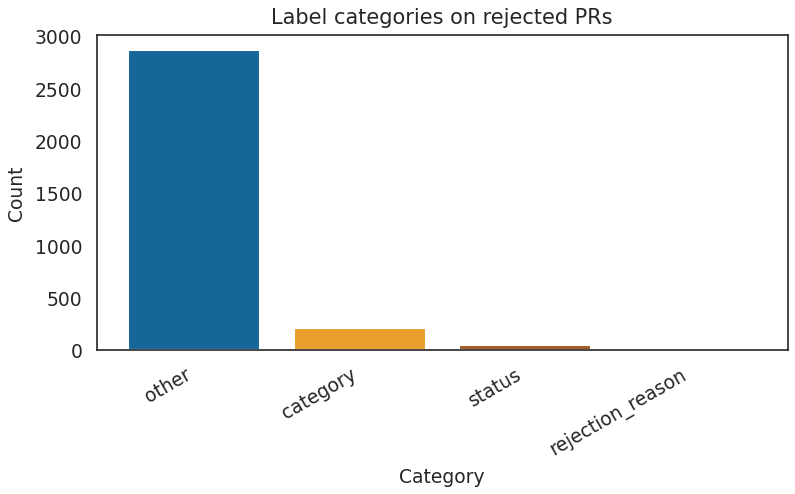

In [36]:
# Label analysis and related issue counts

rejected_pr_ids_fp = set(final_pop[final_pop['label'] == 1]['id'])

timeline_labels = pr_timeline_df_f[
    (pr_timeline_df_f['pr_id'].isin(rejected_pr_ids_fp)) &
    (pr_timeline_df_f['event'] == 'labeled')
].copy()

pr_label_counts = timeline_labels.groupby('pr_id')['label'].count().reset_index(name='label_count')

rejected_with_labels = final_pop[final_pop['label'] == 1].merge(
    pr_label_counts, left_on='id', right_on='pr_id', how='left'
)
rejected_with_labels['label_count'] = rejected_with_labels['label_count'].fillna(0).astype(int)
rejected_with_labels['has_labels']  = rejected_with_labels['label_count'] > 0

label_freq = timeline_labels['label'].value_counts().reset_index()
label_freq.columns = ['label', 'count']

rejection_keywords = ['wontfix', 'invalid', 'duplicate', 'spam', 'closed',
                      'rejected', 'wont-fix', "won't fix"]
status_keywords    = ['stale', 'inactive', 'waiting', 'pending']
category_keywords  = ['bug', 'feature', 'enhancement', 'documentation', 'question']

def categorize_label(lbl):
    lbl_lower = str(lbl).lower()
    if any(kw in lbl_lower for kw in rejection_keywords):
        return 'rejection_reason'
    elif any(kw in lbl_lower for kw in status_keywords):
        return 'status'
    elif any(kw in lbl_lower for kw in category_keywords):
        return 'category'
    return 'other'

label_freq['category'] = label_freq['label'].apply(categorize_label)
category_counts = label_freq.groupby('category')['count'].sum().sort_values(ascending=False)

_total_rej   = len(rejected_with_labels)
_with_labels = int(rejected_with_labels['has_labels'].sum())
print(f"Rejected PRs (final_pop): {_total_rej:,}")
print(f"  With labels:    {_with_labels:,} ({_with_labels/_total_rej*100:.1f}%)")
print(f"  Without labels: {_total_rej-_with_labels:,}")
print(f"\nLabel categories:\n{category_counts}")

# Related issue counts
rel_counts = related_issue_df_f.groupby('pr_id').size().reset_index(name='n_issues')

_merged_issues = final_pop[['id', 'label']].merge(
    rel_counts, left_on='id', right_on='pr_id', how='left'
)
_merged_issues['n_issues'] = _merged_issues['n_issues'].fillna(0).astype(int)
_merged_issues['issue_group'] = _merged_issues['n_issues'].clip(upper=3).map(
    {0: '0', 1: '1', 2: '2', 3: '3+'}
)

issue_group_stats = (
    _merged_issues.groupby('issue_group')['label']
    .agg(n='count', n_rejected='sum')
    .assign(rejection_rate=lambda d: d['n_rejected'] / d['n'])
    .reset_index()
)

print('\nRelated issue count distribution:')
print(issue_group_stats.to_string(index=False))

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.bar(category_counts.index, category_counts.values,
       color=CATEGORICAL_PALETTE[:len(category_counts)])
ax.set_title("Label categories on rejected PRs")
ax.set_xlabel("Category")
ax.set_ylabel("Count")
ax.tick_params(axis="x", labelrotation=30)
plt.setp(ax.get_xticklabels(), ha="right")
ax.title.set_fontsize(10)
ax.xaxis.label.set_fontsize(9)
ax.yaxis.label.set_fontsize(9)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig_p3_label_categories.pdf"))
plt.show()

/tmp/ipykernel_2342/3741366529.py:11: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2342/3741366529.py:12: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.savefig(os.path.join(OUT_DIR, "fig_p3_rejection_reasons.pdf"))
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


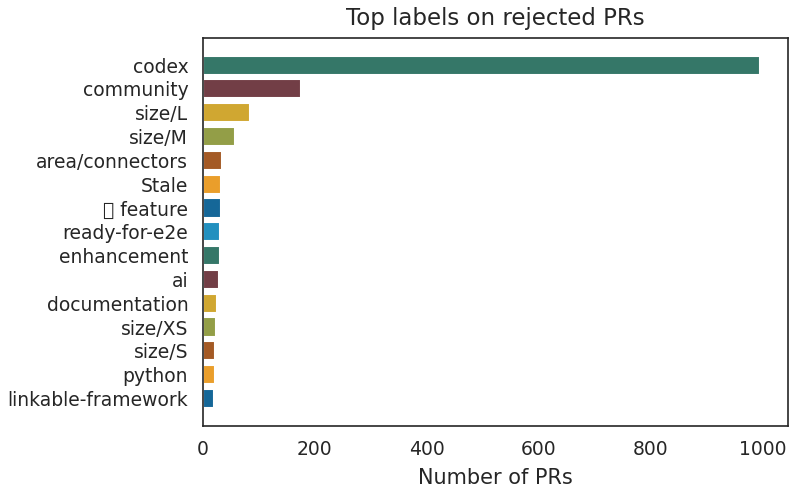

In [37]:
# Typical rejection reasons (labels on rejected PRs)

top_labels_chart = label_freq.head(15).sort_values('count', ascending=True)

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.barh(top_labels_chart['label'], top_labels_chart['count'],
        color=(CATEGORICAL_PALETTE * 2)[:len(top_labels_chart)])
ax.set_xlabel("Number of PRs")
ax.set_title("Top labels on rejected PRs")

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig_p3_rejection_reasons.pdf"))
plt.show()

**Finding:** Labels from event in pr_timeline are not informative enough to be rejection reasons. Moreover, this carries leakage as not all pr events are added before PR submission time.

### Agent System

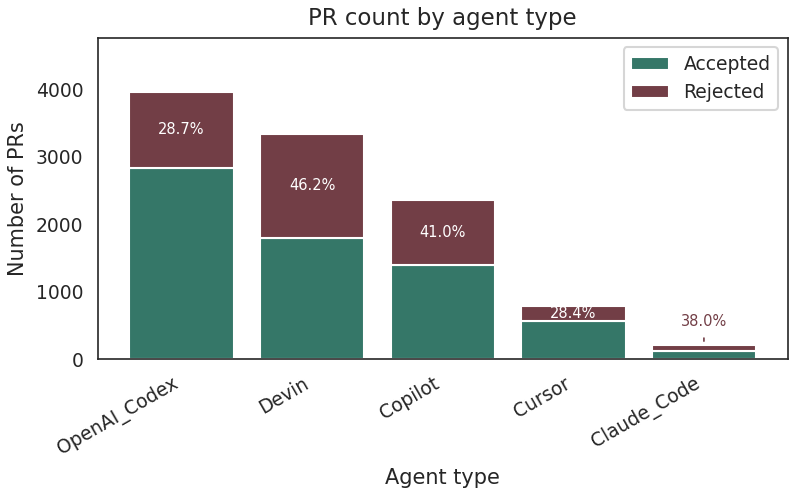

In [38]:
# PRs by agent type

agent_stats = (
    final_pop
    .groupby("agent")["label"]
    .agg(
        n_accepted=lambda x: (x == 0).sum(),
        n_rejected=lambda x: (x == 1).sum(),
    )
    .reset_index()
)
agent_stats["total"] = agent_stats["n_accepted"] + agent_stats["n_rejected"]
agent_stats = agent_stats.sort_values("total", ascending=False)

categories       = agent_stats["agent"].tolist()
accepted_counts  = agent_stats["n_accepted"].tolist()
rejected_counts  = agent_stats["n_rejected"].tolist()
rejection_rates  = (agent_stats["n_rejected"] / agent_stats["total"]).tolist()

max_total = max(a + r for a, r in zip(accepted_counts, rejected_counts))
MIN_INNER = 120

_outside_tops = [a + r for a, r in zip(accepted_counts, rejected_counts) if r < MIN_INNER]
outside_y     = (max(_outside_tops) if _outside_tops else max_total * 0.15) + max_total * 0.06

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.bar(categories, accepted_counts, color=COLOR_ACCEPTED, label="Accepted")
bars_rej = ax.bar(categories, rejected_counts, bottom=accepted_counts,
                  color=COLOR_REJECTED, label="Rejected")

for bar_r, acc, rej, rate in zip(bars_rej, accepted_counts, rejected_counts, rejection_rates):
    bar_x = bar_r.get_x() + bar_r.get_width() / 2
    top   = acc + rej
    if rej >= MIN_INNER:
        ax.text(bar_x, acc + rej / 2, f"{rate:.1%}",
                ha="center", va="center", fontsize=7, color="white")
    else:
        ax.annotate(
            f"{rate:.1%}",
            xy=(bar_x, top), xytext=(bar_x, outside_y),
            ha="center", va="bottom", fontsize=7, color=COLOR_REJECTED,
            arrowprops=dict(arrowstyle="-", color=COLOR_REJECTED, lw=0.8),
        )

ax.set_ylim(0, max(max_total * 1.2, outside_y * 1.12))
ax.legend()
ax.set_title("PR count by agent type")
ax.set_xlabel("Agent type")
ax.set_ylabel("Number of PRs")
ax.tick_params(axis="x", labelrotation=30)
plt.setp(ax.get_xticklabels(), ha="right")

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig_p3_by_agent.pdf"))
plt.show()

### Task Type

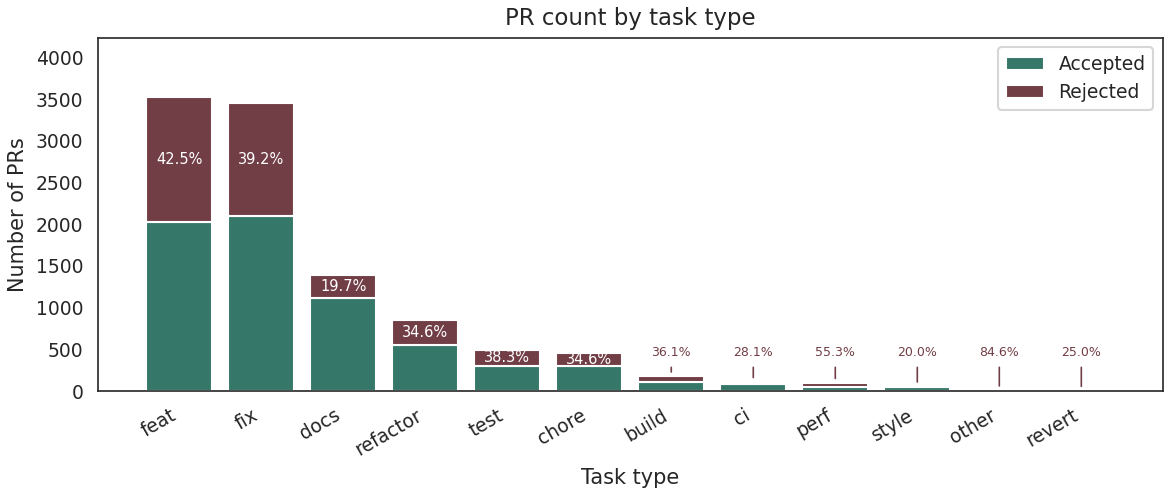

In [39]:
# PRs by task type

eda_pr_task_fp = final_pop.merge(
    pr_task_type_df_f, left_on="id", right_on="pr_id", how="left"
)
task_stats = (
    eda_pr_task_fp
    .groupby("type")["label"]
    .agg(
        n_accepted=lambda x: (x == 0).sum(),
        n_rejected=lambda x: (x == 1).sum(),
    )
    .reset_index()
)
task_stats["total"] = task_stats["n_accepted"] + task_stats["n_rejected"]
task_stats = task_stats.sort_values("total", ascending=False)

categories       = task_stats["type"].tolist()
accepted_counts  = task_stats["n_accepted"].tolist()
rejected_counts  = task_stats["n_rejected"].tolist()
rejection_rates  = (task_stats["n_rejected"] / task_stats["total"]).tolist()

max_total = max(a + r for a, r in zip(accepted_counts, rejected_counts))
MIN_INNER = 120

# All outside labels share the same y so they form a tidy horizontal band
_outside_tops = [a + r for a, r in zip(accepted_counts, rejected_counts) if r < MIN_INNER]
outside_y     = (max(_outside_tops) if _outside_tops else max_total * 0.15) + max_total * 0.06

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(categories, accepted_counts, color=COLOR_ACCEPTED, label="Accepted")
bars_rej = ax.bar(categories, rejected_counts, bottom=accepted_counts,
                  color=COLOR_REJECTED, label="Rejected")

for bar_r, acc, rej, rate in zip(bars_rej, accepted_counts, rejected_counts, rejection_rates):
    bar_x = bar_r.get_x() + bar_r.get_width() / 2
    top   = acc + rej
    if rej >= MIN_INNER:
        ax.text(bar_x, acc + rej / 2, f"{rate:.1%}",
                ha="center", va="center", fontsize=7, color="white")
    else:
        ax.annotate(
            f"{rate:.1%}",
            xy=(bar_x, top), xytext=(bar_x, outside_y),
            ha="center", va="bottom", fontsize=6, color=COLOR_REJECTED,
            arrowprops=dict(arrowstyle="-", color=COLOR_REJECTED, lw=0.8),
        )

ax.set_ylim(0, max(max_total * 1.2, outside_y * 1.12))
ax.legend()
ax.set_title("PR count by task type")
ax.set_xlabel("Task type")
ax.set_ylabel("Number of PRs")
ax.tick_params(axis="x", labelrotation=30)
plt.setp(ax.get_xticklabels(), ha="right")

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig_p3_by_task_type.pdf"))
plt.show()

### Programming Language

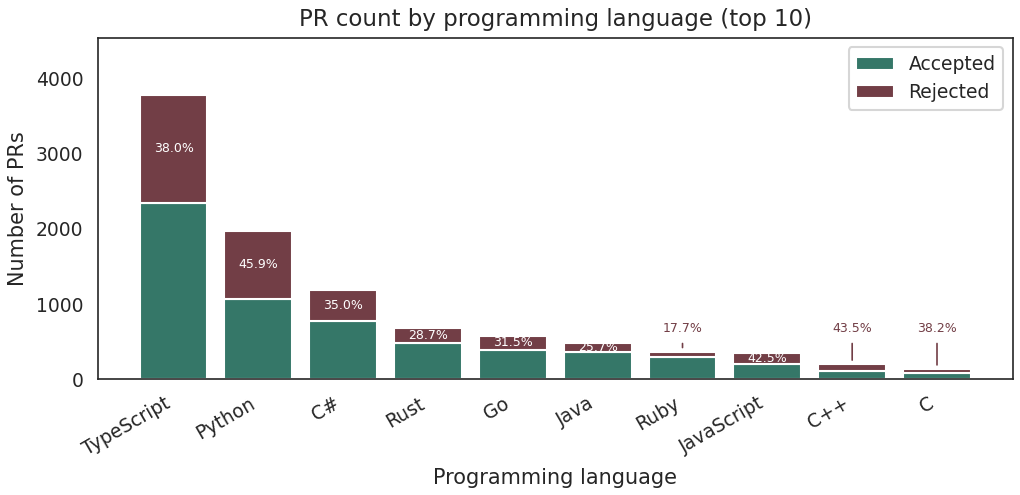

In [40]:
# PRs by programming language (top 10)

eda_pr_lang_fp = final_pop.merge(
    repo_df_f[['repo_id', 'language']], on='repo_id', how='left'
)
top_langs      = eda_pr_lang_fp['language'].value_counts().head(10).index
eda_pr_lang_fp = eda_pr_lang_fp[eda_pr_lang_fp['language'].isin(top_langs)]

lang_stats = (
    eda_pr_lang_fp
    .groupby("language")["label"]
    .agg(
        n_accepted=lambda x: (x == 0).sum(),
        n_rejected=lambda x: (x == 1).sum(),
    )
    .reset_index()
)
lang_stats["total"] = lang_stats["n_accepted"] + lang_stats["n_rejected"]
lang_stats = lang_stats.sort_values("total", ascending=False)

categories       = lang_stats["language"].tolist()
accepted_counts  = lang_stats["n_accepted"].tolist()
rejected_counts  = lang_stats["n_rejected"].tolist()
rejection_rates  = (lang_stats["n_rejected"] / lang_stats["total"]).tolist()

max_total = max(a + r for a, r in zip(accepted_counts, rejected_counts))
MIN_INNER = 120

_outside_tops = [a + r for a, r in zip(accepted_counts, rejected_counts) if r < MIN_INNER]
outside_y     = (max(_outside_tops) if _outside_tops else max_total * 0.15) + max_total * 0.06

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(categories, accepted_counts, color=COLOR_ACCEPTED, label="Accepted")
bars_rej = ax.bar(categories, rejected_counts, bottom=accepted_counts,
                  color=COLOR_REJECTED, label="Rejected")

for bar_r, acc, rej, rate in zip(bars_rej, accepted_counts, rejected_counts, rejection_rates):
    bar_x = bar_r.get_x() + bar_r.get_width() / 2
    top   = acc + rej
    if rej >= MIN_INNER:
        ax.text(bar_x, acc + rej / 2, f"{rate:.1%}",
                ha="center", va="center", fontsize=6, color="white")
    else:
        ax.annotate(
            f"{rate:.1%}",
            xy=(bar_x, top), xytext=(bar_x, outside_y),
            ha="center", va="bottom", fontsize=6, color=COLOR_REJECTED,
            arrowprops=dict(arrowstyle="-", color=COLOR_REJECTED, lw=0.8),
        )

ax.set_ylim(0, max(max_total * 1.2, outside_y * 1.12))
ax.legend()
ax.set_title("PR count by programming language (top 10)")
ax.set_xlabel("Programming language")
ax.set_ylabel("Number of PRs")
ax.tick_params(axis="x", labelrotation=30)
plt.setp(ax.get_xticklabels(), ha="right")

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig_p3_by_language.pdf"))
plt.show()

### Comment and Reviews
This section analyzes the PR comments and reviews and will not be used for the thesis as these kinds of information are posted after the PR submission already. Using comments as features in the models will constitute as information leakage; this analysis is exploratory only.

In [41]:
# Comment and review counts; bot vs human breakdown (data prep)
pr_comment_counts = (
    pr_comments_df_f
    .groupby('pr_id')
    .size()
    .reset_index(name='num_comments')
)

pr_review_counts = (
    pr_reviews_df_f
    .groupby('pr_id')
    .size()
    .reset_index(name='num_reviews')
)

pr_review_to_pr = pr_reviews_df_f[['id', 'pr_id']].rename(columns={'id': 'review_id'})
pr_review_comment_counts = (
    pr_review_comments_v2_df_f
    .merge(pr_review_to_pr, left_on='pull_request_review_id', right_on='review_id', how='left')
    .groupby('pr_id')
    .size()
    .reset_index(name='num_review_comments')
)

eda_pr_review_df = eda_pr_closed_df.copy()
eda_pr_review_df = eda_pr_review_df.merge(pr_comment_counts, left_on='id', right_on='pr_id', how='left')
eda_pr_review_df = eda_pr_review_df.merge(pr_review_counts, left_on='id', right_on='pr_id', how='left')
eda_pr_review_df = eda_pr_review_df.merge(pr_review_comment_counts, left_on='id', right_on='pr_id', how='left')
eda_pr_review_df[['num_comments', 'num_reviews', 'num_review_comments']] = (
    eda_pr_review_df[['num_comments', 'num_reviews', 'num_review_comments']].fillna(0)
)

rejected_pr_ids_fp = set(final_pop[final_pop['label'] == 1]['id'])

issue_comments = pr_comments_df_f[pr_comments_df_f['pr_id'].isin(rejected_pr_ids_fp)].copy()
issue_comments['comment_type'] = 'issue_comment'

reviews = pr_reviews_df_f[pr_reviews_df_f['pr_id'].isin(rejected_pr_ids_fp)].copy()
reviews['comment_type'] = 'review'

pr_review_to_pr_b = pr_reviews_df_f[['id', 'pr_id']].rename(columns={'id': 'review_id'})
inline_comments = pr_review_comments_v2_df_f.merge(
    pr_review_to_pr_b, left_on='pull_request_review_id', right_on='review_id', how='left'
)
inline_comments = inline_comments[inline_comments['pr_id'].isin(rejected_pr_ids_fp)].copy()
inline_comments['comment_type'] = 'inline_comment'

all_comments = pd.concat([
    issue_comments[['pr_id', 'user_type', 'comment_type']],
    reviews[['pr_id', 'user_type', 'comment_type']],
    inline_comments[['pr_id', 'user_type', 'comment_type']],
], ignore_index=True)

all_comments['user_type'] = all_comments['user_type'].str.lower().fillna('unknown')
all_comments['is_bot']    = all_comments['user_type'] == 'bot'

_total = len(all_comments)
_bot   = int(all_comments['is_bot'].sum())
_hum   = _total - _bot
print(f"All comments (final_pop rejected PRs): {_total:,}")
print(f"  Bot:   {_bot:,} ({_bot/_total*100:.1f}%)")
print(f"  Human: {_hum:,} ({_hum/_total*100:.1f}%)")

All comments (final_pop rejected PRs): 16,233
  Bot:   9,841 (60.6%)
  Human: 6,392 (39.4%)


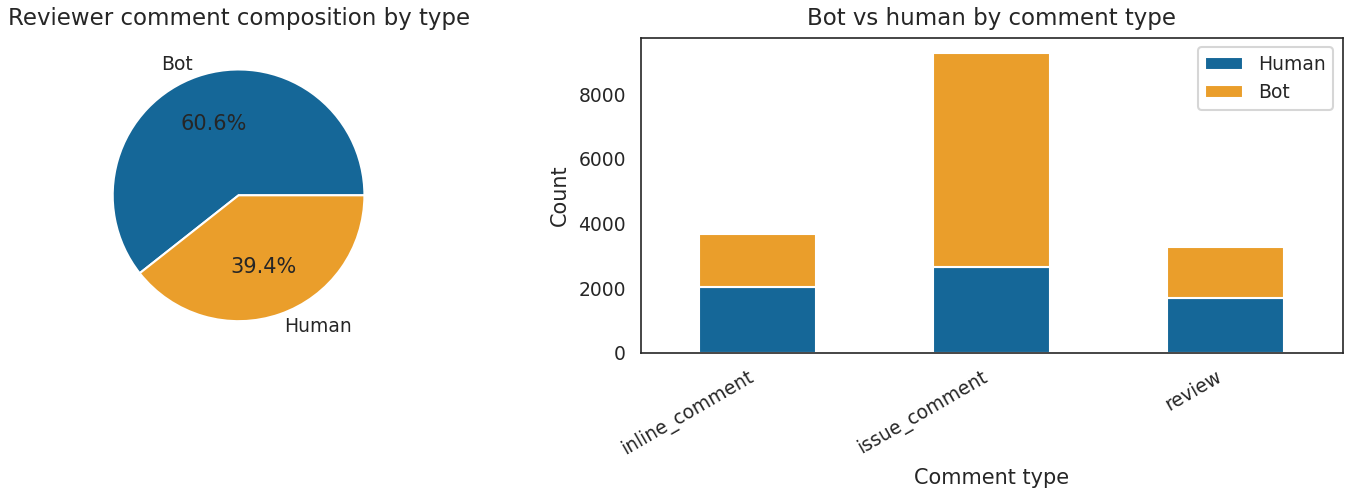

In [42]:
# Reviewer comment composition (bot vs human)

_bot_total = all_comments['is_bot'].sum()
_hum_total = len(all_comments) - _bot_total

type_analysis = (
    all_comments
    .groupby(['comment_type', 'is_bot'])
    .size()
    .unstack(fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].pie(
    [_bot_total, _hum_total],
    labels=['Bot', 'Human'],
    autopct='%1.1f%%',
)
axes[0].set_title("Reviewer comment composition by type")

type_analysis.plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_xlabel("Comment type")
axes[1].set_ylabel("Count")
axes[1].set_title("Bot vs human by comment type")
axes[1].legend(["Human", "Bot"])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig_p3_comments.pdf"))
plt.show()

**Finding:** Most reviewers are bots, hence, post-submission rejection labels from PR Reviews should be treated with caution. This finding is included in the Thesis' Threats to Validity in Chapter 6.

### Related Issues

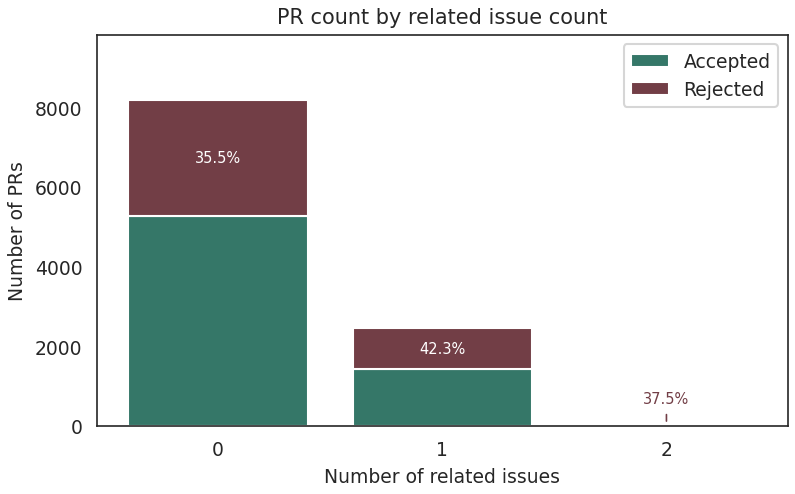

In [43]:
# Related issues — count distribution and rejection rate
_acc_issues  = (issue_group_stats['n'] - issue_group_stats['n_rejected']).tolist()
_rej_issues  = issue_group_stats['n_rejected'].tolist()
_rates_iss   = issue_group_stats['rejection_rate'].tolist()
_xlabels_iss = issue_group_stats['issue_group'].astype(str).tolist()

max_total = max(a + r for a, r in zip(_acc_issues, _rej_issues))
MIN_INNER = 120

_outside_tops = [a + r for a, r in zip(_acc_issues, _rej_issues)
                 if r < MIN_INNER]
outside_y     = (max(_outside_tops) if _outside_tops else max_total * 0.15) + max_total * 0.06

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.bar(_xlabels_iss, _acc_issues, color=COLOR_ACCEPTED, label="Accepted")
bars_rej_iss = ax.bar(_xlabels_iss, _rej_issues, bottom=_acc_issues,
                      color=COLOR_REJECTED, label="Rejected")

for bar_r, acc, rej, rate in zip(bars_rej_iss, _acc_issues, _rej_issues, _rates_iss):
    bar_x = bar_r.get_x() + bar_r.get_width() / 2
    top   = acc + rej
    if rej >= MIN_INNER:
        ax.text(bar_x, acc + rej / 2, f"{rate:.1%}",
                ha="center", va="center", fontsize=7, color="white")
    else:
        ax.annotate(
            f"{rate:.1%}",
            xy=(bar_x, top), xytext=(bar_x, outside_y),
            ha="center", va="bottom", fontsize=7, color=COLOR_REJECTED,
            arrowprops=dict(arrowstyle="-", color=COLOR_REJECTED, lw=0.8),
        )

ax.set_ylim(0, max(max_total * 1.2, outside_y * 1.12))
ax.legend()
ax.set_title("PR count by related issue count")
ax.set_xlabel("Number of related issues")
ax.set_ylabel("Number of PRs")
ax.title.set_fontsize(10)
ax.xaxis.label.set_fontsize(9)
ax.yaxis.label.set_fontsize(9)

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig_p3_related_issues.pdf"))
plt.show()

In [44]:
# PR closure timestamp + related-issue timing join
# Join path: related_issue_df_f -> issue_df_f -> final_pop

# Detect PR key and close timestamp column
_pr_key = next((c for c in ["id", "pr_id", "pull_request_id"] if c in final_pop.columns), None)

if "closed_at" in final_pop.columns:
    pr_close_col = "closed_at"
elif "merged_at" in final_pop.columns:
    pr_close_col = "_close_proxy"
    final_pop = final_pop.copy()
    final_pop["_close_proxy"] = pd.to_datetime(final_pop["merged_at"], utc=True, errors="coerce")
    print("WARNING: closed_at not found. Using merged_at proxy (null for rejected PRs).")
else:
    pr_close_col = None
    print("ERROR: no closure timestamp in final_pop.")

print(f"PR key: '{_pr_key}' | close col: '{pr_close_col}'")

# Issue side
_issue_cols = ["id"] + [c for c in ["created_at", "closed_at"] if c in issue_df_f.columns]
issue_work = issue_df_f[_issue_cols].copy()
for col in ["created_at", "closed_at"]:
    if col in issue_work.columns:
        issue_work[col] = pd.to_datetime(issue_work[col], utc=True, errors="coerce")
issue_work = issue_work.rename(columns={"created_at": "issue_created_at",
                                         "closed_at": "issue_closed_at"})

# PR side
_pr_cols = list(dict.fromkeys(
    [c for c in [_pr_key, pr_close_col, "created_at", "label"] if c and c in final_pop.columns]
))
pr_work = final_pop[_pr_cols].copy()
for col in [pr_close_col, "created_at"]:
    if col and col in pr_work.columns:
        pr_work[col] = pd.to_datetime(pr_work[col], utc=True, errors="coerce")
pr_work = pr_work.rename(columns={"created_at": "pr_created_at",
                                    pr_close_col: "pr_closed_at"})

# Join
timing_df = related_issue_df_f.merge(
    issue_work, left_on="issue_id", right_on="id", how="left"
).drop(columns=["id"], errors="ignore")

timing_df = timing_df.merge(
    pr_work, left_on="pr_id", right_on=_pr_key, how="inner"
)

# Timing flags
def _flag(a, b):
    null_mask = a.isna() | b.isna()
    return np.where(null_mask, np.nan, (a < b).astype(float))

if "issue_created_at" in timing_df.columns:
    if "pr_created_at" in timing_df.columns:
        timing_df["issue_created_before_pr_submitted"] = _flag(
            timing_df["issue_created_at"], timing_df["pr_created_at"]
        )
    timing_df["issue_created_before_pr_closed"] = _flag(
        timing_df["issue_created_at"], timing_df["pr_closed_at"]
    )

print(f"timing_df rows:   {len(timing_df):,}")
print(f"Unique PRs:       {timing_df['pr_id'].nunique():,}")
print(f"Unique issues:    {timing_df['issue_id'].nunique():,}")
if "issue_created_at" in timing_df.columns:
    n_before = int((timing_df["issue_created_before_pr_submitted"] == 1.0).sum())
    n_total  = timing_df["issue_created_before_pr_submitted"].notna().sum()
    print(f"Issue predates PR submission: {n_before:,} / {n_total:,} ({100*n_before/n_total:.1f}% of non-null)")


PR key: 'id' | close col: 'closed_at'
timing_df rows:   2,475
Unique PRs:       2,467
Unique issues:    2,350
Issue predates PR submission: 2,465 / 2,475 (99.6% of non-null)


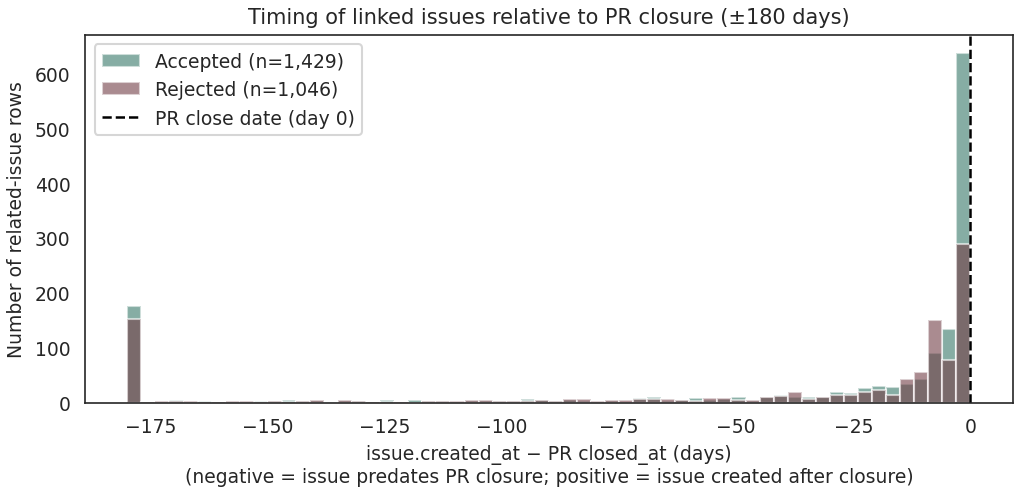

In [45]:
# Related issue timing histogram
# Negative delta = issue predates PR closure (pre-decision signal, no leakage).
# Positive delta = issue created after PR closure (post-hoc, potential leakage).

if timing_df is None or "issue_created_at" not in timing_df.columns:
    print("No timing data available — skipping plot (run Cell 34a first).")
else:
    plot_df = timing_df[
        timing_df["issue_created_at"].notna() & timing_df["pr_closed_at"].notna()
    ].copy()

    plot_df["delta_days"] = (
        (plot_df["issue_created_at"] - plot_df["pr_closed_at"]).dt.total_seconds() / 86400
    ).clip(-180, 180)

    fig, ax = plt.subplots(figsize=(7, 3.5))

    label_cfg = {
        0: {"color": COLOR_ACCEPTED, "label": "Accepted"},
        1: {"color": COLOR_REJECTED,  "label": "Rejected"},
    }
    for lbl, cfg in label_cfg.items():
        vals = plot_df[plot_df["label"] == lbl]["delta_days"]
        ax.hist(vals, bins=60, alpha=0.6, color=cfg["color"],
                label=f"{cfg['label']} (n={len(vals):,})")

    ax.axvline(0, color="black", linewidth=1.2, linestyle="--", label="PR close date (day 0)")
    ax.set_xlabel(
        "issue.created_at \u2212 PR closed_at (days)\n"
        "(negative = issue predates PR closure; positive = issue created after closure)"
    )
    ax.set_ylabel("Number of related-issue rows")
    ax.set_title("Timing of linked issues relative to PR closure (\u00b1180 days)")
    ax.legend()
    ax.title.set_fontsize(10)
    ax.xaxis.label.set_fontsize(9)
    ax.yaxis.label.set_fontsize(9)
    plt.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, "fig_p3_related_issue_timing.pdf"))
    plt.show()


### File Entropy

In [46]:
# File entropy computation

from features.metadata_features import _compute_entropy

_file_line_counts = (
    pr_commit_details_df_f
    .assign(lines_changed=lambda d: d['additions'].fillna(0) + d['deletions'].fillna(0))
    .groupby(['pr_id', 'filename'], as_index=False)['lines_changed']
    .sum()
    .groupby('pr_id')['lines_changed']
    .apply(list)
    .rename('file_changes')
    .reset_index()
)

final_pop = final_pop.merge(
    _file_line_counts, left_on='id', right_on='pr_id', how='left'
)
final_pop['file_changes'] = final_pop['file_changes'].apply(
    lambda x: x if isinstance(x, list) else []
)

def safe_entropy(file_changes):
    if not isinstance(file_changes, list) or len(file_changes) == 0:
        return 0.0
    return _compute_entropy(file_changes)

final_pop['file_entropy'] = final_pop['file_changes'].apply(safe_entropy)

bins_ent   = [-0.001, 0.0, 0.5, 1.0, 1.5, float('inf')]
labels_ent = ['0.0 (single file)', '0.0-0.5', '0.5-1.0', '1.0-1.5', '>1.5']

final_pop['entropy_bin'] = pd.cut(
    final_pop['file_entropy'],
    bins=bins_ent,
    labels=labels_ent,
    include_lowest=True,
)

entropy_stats = (
    final_pop.groupby('entropy_bin', observed=True)['label']
    .agg(n='count', n_rejected='sum')
    .assign(rejection_rate=lambda d: d['n_rejected'] / d['n'])
    .reset_index()
)
entropy_stats['pct_of_prs'] = 100 * entropy_stats['n'] / len(final_pop)

print('Rejection rate by file entropy bin:')
print(entropy_stats[['entropy_bin', 'n', 'pct_of_prs', 'rejection_rate']].to_string(index=False))

Rejection rate by file entropy bin:
      entropy_bin    n  pct_of_prs  rejection_rate
0.0 (single file) 2908   27.310293        0.264787
          0.0-0.5 1092   10.255447        0.437729
          0.5-1.0 2087   19.599925        0.428366
          1.0-1.5 1619   15.204733        0.434836
             >1.5 2942   27.629602        0.374575


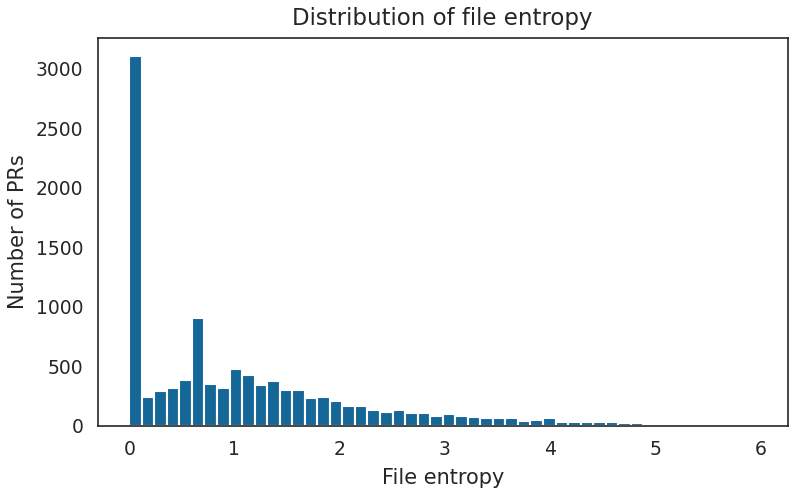

In [47]:
# File entropy distribution

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.hist(final_pop['file_entropy'], bins=50)
ax.set_title("Distribution of file entropy")
ax.set_xlabel("File entropy")
ax.set_ylabel("Number of PRs")

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig_p3_file_entropy_dist.pdf"))
plt.show()

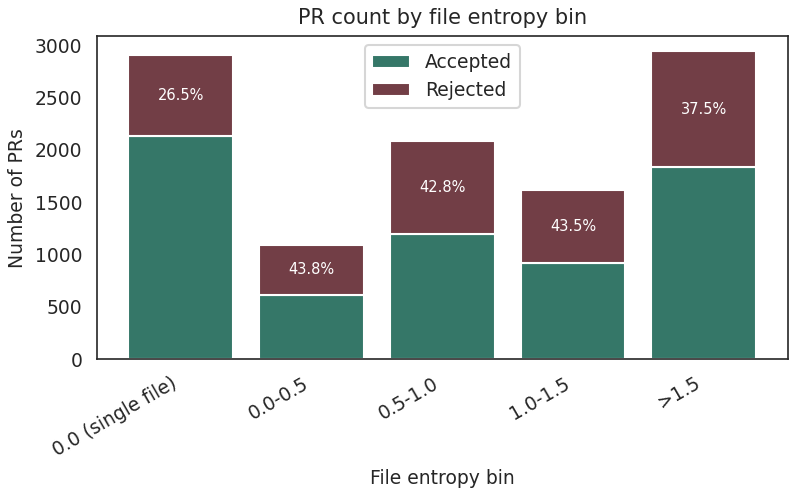

In [48]:
# Accepted vs rejected PRs by file entropy bin

_acc_ent     = (entropy_stats['n'] - entropy_stats['n_rejected']).tolist()
_rej_ent     = entropy_stats['n_rejected'].tolist()
_rates_ent   = entropy_stats['rejection_rate'].tolist()
_xlabels_ent = entropy_stats['entropy_bin'].astype(str).tolist()

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.bar(_xlabels_ent, _acc_ent, color=COLOR_ACCEPTED, label="Accepted")
bars_rej_ent = ax.bar(_xlabels_ent, _rej_ent, bottom=_acc_ent,
                      color=COLOR_REJECTED, label="Rejected")

for bar, acc, rate in zip(bars_rej_ent, _acc_ent, _rates_ent):
    bar_x = bar.get_x() + bar.get_width() / 2
    bar_y = acc + bar.get_height() / 2
    ax.text(bar_x, bar_y, f"{rate:.1%}",
            ha="center", va="center", fontsize=7, color="white")

ax.legend()
ax.set_title("PR count by file entropy bin")
ax.set_xlabel("File entropy bin")
ax.set_ylabel("Number of PRs")
ax.tick_params(axis="x", labelrotation=30)
plt.setp(ax.get_xticklabels(), ha="right")
ax.title.set_fontsize(10)
ax.xaxis.label.set_fontsize(9)
ax.yaxis.label.set_fontsize(9)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig_p3_entropy_stacked.pdf"))
plt.show()

### Metadata Correlation Matrix

In [49]:
# Metadata correlation: data prep
# Builds meta_corr_df with all scalar metadata features for final_pop.
# Feature list mirrors src/features/metadata_features.py (numeric + boolean/flag groups).
# OHE categoricals (agent, language, license, task_type) and cyclic time features
# are excluded from the correlation matrix as they are not ordinal.

from features.metadata_features import (
    _detect_has_plan,
    _is_experimental_submission,
    _empty_description,
    _touches_ci,
    _touches_tests,
    _touches_config,
)

# Per-PR aggregates
_nfiles = (
    pr_commit_details_df_f
    .groupby('pr_id')['filename']
    .nunique()
    .reset_index(name='num_files_changed')
)
_ncommits = (
    pr_commits_df_f
    .groupby('pr_id')
    .size()
    .reset_index(name='num_commits')
)
_rel_counts = (
    related_issue_df_f
    .groupby('pr_id')
    .size()
    .reset_index(name='related_issue_count')
)
_filenames_per_pr = (
    pr_commit_details_df_f
    .groupby('pr_id')['filename']
    .apply(list)
    .reset_index(name='filenames')
)

# Base: final_pop scalar columns
meta_corr_df = final_pop[['id', 'label', 'title', 'body', 'repo_id']].copy()
meta_corr_df['body_length'] = meta_corr_df['body'].fillna('').str.len()
meta_corr_df['has_plan'] = meta_corr_df['body'].apply(_detect_has_plan).astype(int)
meta_corr_df['is_experimental_submission'] = meta_corr_df.apply(
    lambda r: _is_experimental_submission(r['title'], r['body']), axis=1
).astype(int)
meta_corr_df['empty_description'] = meta_corr_df['body'].apply(_empty_description).astype(int)

# file_entropy
meta_corr_df['file_entropy'] = final_pop['file_entropy'].values

# diff stats
meta_corr_df = meta_corr_df.merge(
    pr_diff_stats[['pr_id', 'total_additions', 'total_deletions', 'total_changes']],
    left_on='id', right_on='pr_id', how='left'
).drop(columns=['pr_id'])

# num_files_changed, num_commits
meta_corr_df = meta_corr_df.merge(_nfiles,   left_on='id', right_on='pr_id', how='left').drop(columns=['pr_id'])
meta_corr_df = meta_corr_df.merge(_ncommits, left_on='id', right_on='pr_id', how='left').drop(columns=['pr_id'])

# related_issue_count
meta_corr_df = meta_corr_df.merge(_rel_counts, left_on='id', right_on='pr_id', how='left').drop(columns=['pr_id'])
meta_corr_df['related_issue_count'] = meta_corr_df['related_issue_count'].fillna(0).astype(int)

# stars, forks from repo_df_f
_fork_col = next((c for c in repo_df_f.columns if 'fork' in c.lower()), None)
_repo_keep = ['repo_id', 'stars'] + ([_fork_col] if _fork_col else [])
_repo_meta = repo_df_f[_repo_keep].copy()
if _fork_col and _fork_col != 'forks':
    _repo_meta = _repo_meta.rename(columns={_fork_col: 'forks'})
elif not _fork_col:
    _repo_meta['forks'] = 0
meta_corr_df = meta_corr_df.merge(_repo_meta, on='repo_id', how='left')

# file-type flags from filenames
meta_corr_df = meta_corr_df.merge(_filenames_per_pr, left_on='id', right_on='pr_id', how='left').drop(columns=['pr_id'])
meta_corr_df['filenames'] = meta_corr_df['filenames'].apply(lambda x: [f for f in x if f is not None] if isinstance(x, list) else [])
meta_corr_df['touches_ci']     = meta_corr_df['filenames'].apply(_touches_ci).astype(int)
meta_corr_df['touches_tests']  = meta_corr_df['filenames'].apply(_touches_tests).astype(int)
meta_corr_df['touches_config'] = meta_corr_df['filenames'].apply(_touches_config).astype(int)

# fill nulls for numeric cols with no diff data
for col in ['total_additions', 'total_deletions', 'total_changes',
            'num_files_changed', 'num_commits', 'stars', 'forks']:
    meta_corr_df[col] = meta_corr_df[col].fillna(0)

print(f"meta_corr_df shape: {meta_corr_df.shape}")
_nulls = meta_corr_df.isnull().sum()
_nulls = _nulls[_nulls > 0]
if len(_nulls):
    print(f"Null counts:\n{_nulls}")
else:
    print("No nulls in correlation features.")


meta_corr_df shape: (10648, 22)
Null counts:
body    177
dtype: int64


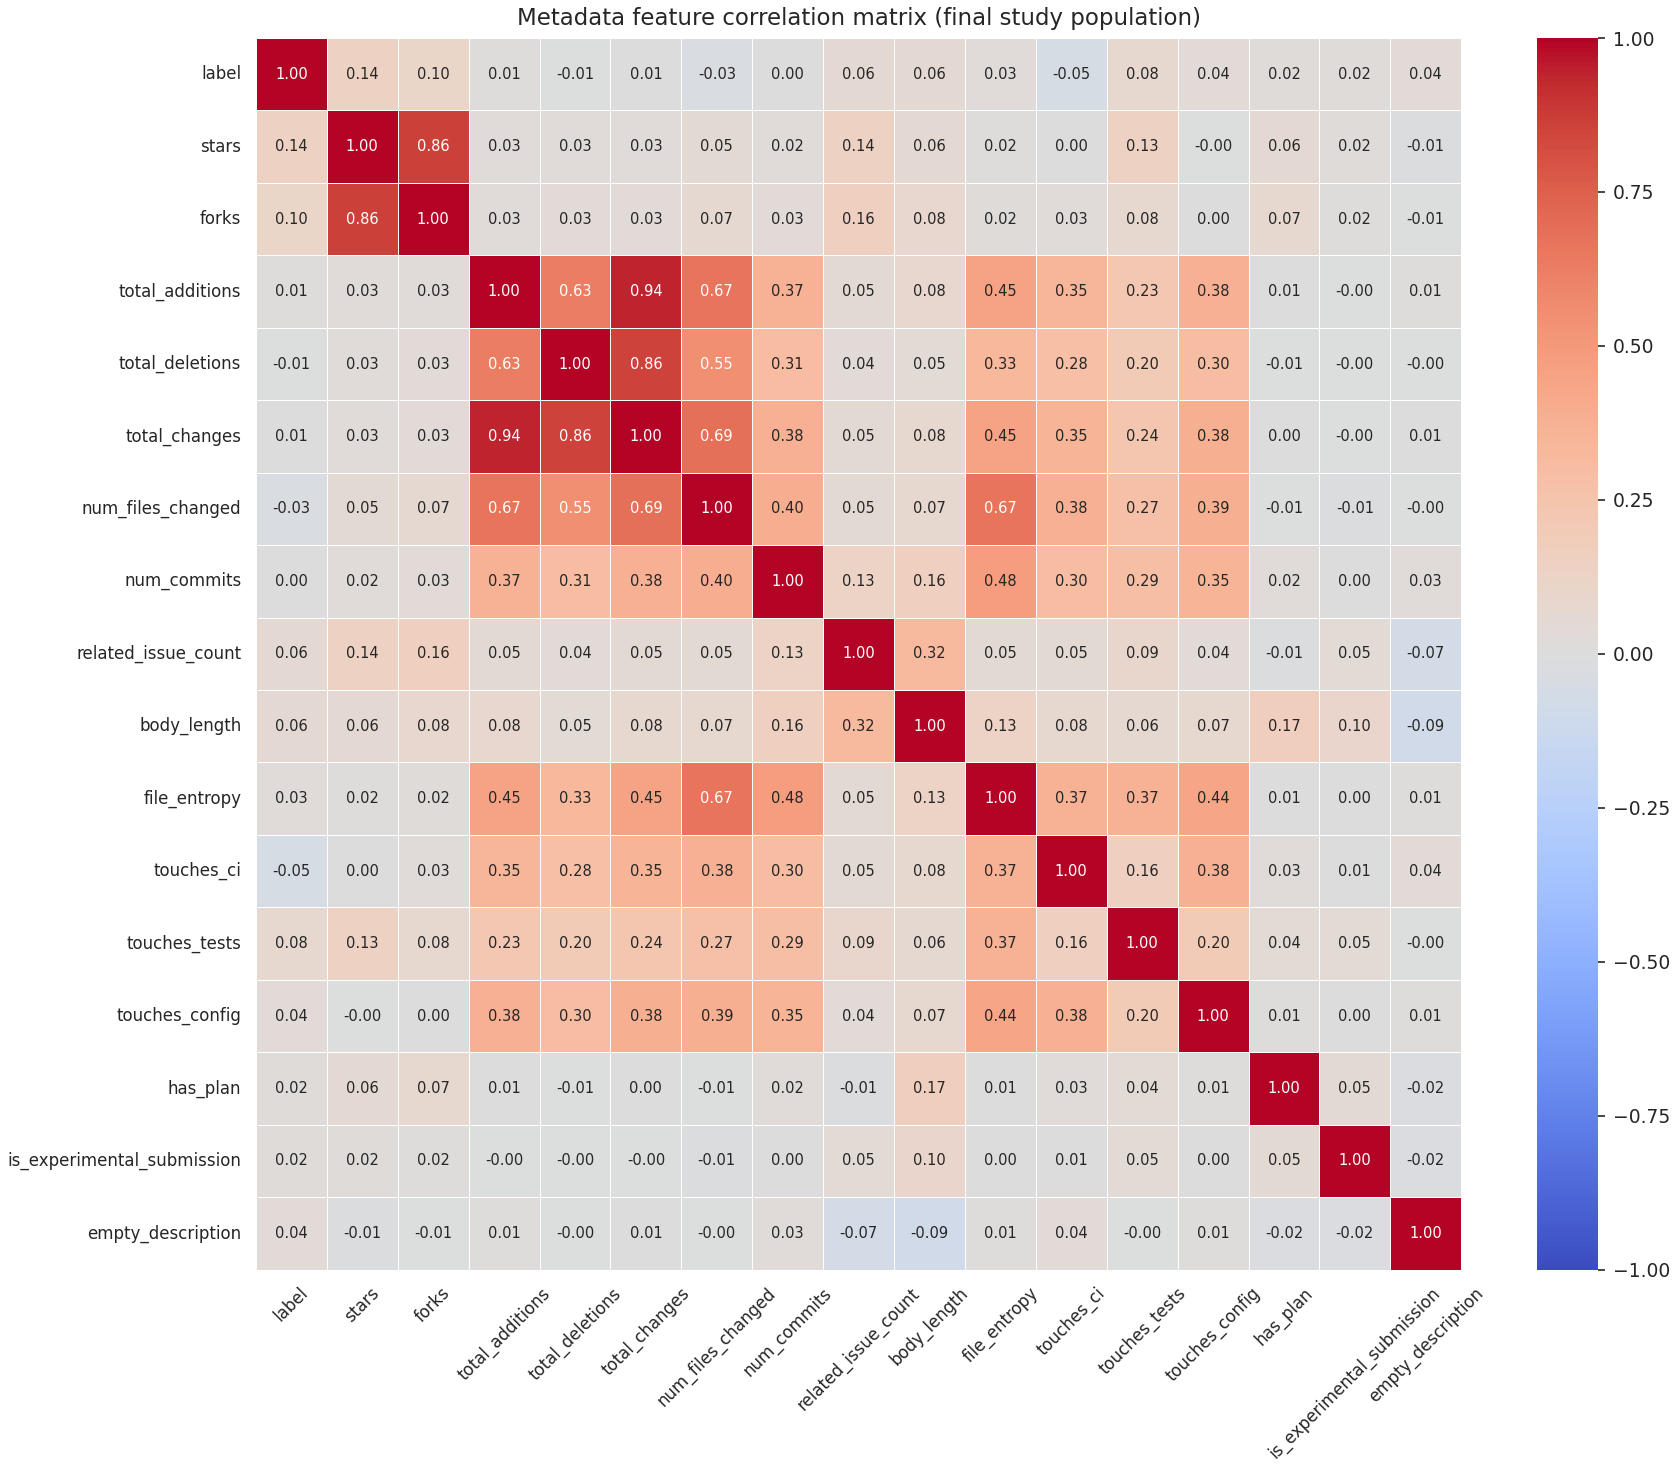

In [50]:
# Metadata feature correlation matrix

CORR_FEATURES = [
    'label',
    'stars', 'forks',
    'total_additions', 'total_deletions', 'total_changes',
    'num_files_changed', 'num_commits',
    'related_issue_count', 'body_length',
    'file_entropy',
    'touches_ci', 'touches_tests', 'touches_config',
    'has_plan', 'is_experimental_submission', 'empty_description',
]

corr_matrix = meta_corr_df[CORR_FEATURES].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    linewidths=0.4, linecolor='white',
    annot_kws={"size": 7},
    ax=ax,
)
ax.set_title("Metadata feature correlation matrix (final study population)")
ax.title.set_fontsize(11)
ax.tick_params(axis='x', labelrotation=45, labelsize=8)
ax.tick_params(axis='y', labelrotation=0, labelsize=8)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig_metadata_correlation.pdf"))
plt.show()
